# 14 — Analyse des résultats (run GPU V100S)

Ce notebook lit les fichiers JSON produits par les notebooks 03→13 (entraînés sur
le serveur GPU UTBM, **3 seeds**, moyenne ± écart-type), affiche les figures et en
donne une **interprétation**. Il est purement analytique : aucun entraînement.

**Trois coûts** sont reportés : coût *données* (acquisition, unique), coût *calcul*
(images vues) et coût *total* (images vues pondérées par leur coût = ancien coût).

In [1]:
pip install pandas numpy matplotlib jupyter ipykernel

Note: you may need to restart the kernel to use updated packages.


## 1) Chargement des résultats

In [2]:
import os
import sys
import json
import importlib

import numpy as np
import pandas as pd
from IPython.display import Image, display, Markdown

for _p in ['/content/drive/MyDrive/UTBM_PF22/src', '../src', 'src', './src']:
    if os.path.isdir(_p) and _p not in sys.path:
        sys.path.insert(0, _p)
import env_config
importlib.reload(env_config)

RES = {'Animals-10': env_config.results_dir('Animals-10'),
       'Imagewoof':  env_config.results_dir('Imagewoof')}
COMP = env_config.comparison_dir()

FILES = [
    ('BL 1(HF)',          'results_baseline_HF.json'),
    ('BL 2(BF)',          'results_baseline_BF.json'),
    ('BL 3(MIXTE)',       'results_baseline_MIXTE.json'),
    ('Strat 1(BF->HF)',   'results_strategy1_transfer_learning.json'),
    ('Strat 2(CoTrain)',  'results_strategy2_cotraining_reweighting.json'),
    ('Strat 3(NoisyStud)','results_strategy3_noisy_student.json'),
]


def load_all(ds):
    out = {}
    for name, fn in FILES:
        p = os.path.join(RES[ds], fn)
        if os.path.exists(p):
            with open(p, 'r', encoding='utf-8') as f:
                out[name] = json.load(f)
    return out


R = {ds: load_all(ds) for ds in RES}
for ds in R:
    print(f"{ds}: {len(R[ds])} modèles -> {list(R[ds])}")


def show(path, width=950):
    """Affiche une image si elle existe."""
    if os.path.exists(path):
        display(Image(filename=path, width=width))
    else:
        print('Figure absente:', path)

Animals-10: 6 modèles -> ['BL 1(HF)', 'BL 2(BF)', 'BL 3(MIXTE)', 'Strat 1(BF->HF)', 'Strat 2(CoTrain)', 'Strat 3(NoisyStud)']
Imagewoof: 5 modèles -> ['BL 1(HF)', 'BL 2(BF)', 'BL 3(MIXTE)', 'Strat 1(BF->HF)', 'Strat 2(CoTrain)']


## 2) Tableaux récapitulatifs (moyenne ± écart-type, 3 coûts)

In [3]:
def recap(ds):
    rows = []
    for name, d in R[ds].items():
        rows.append({
            'Modèle': name,
            'HF (%)':    f"{d['accuracy_HF']:.1f} ± {d.get('accuracy_HF_std', 0):.1f}",
            'BF (%)':    f"{d['accuracy_BF']:.1f} ± {d.get('accuracy_BF_std', 0):.1f}",
            'Mixte (%)': f"{d['accuracy_Mixte']:.1f} ± {d.get('accuracy_Mixte_std', 0):.1f}",
            'Coût données (CA)': int(round(d['data_cost_CA'])),
            'Coût calcul (img)': int(d['compute_images_seen']),
            'Coût total (CA)':   int(round(d['total_cost_CA'])),
        })
    return pd.DataFrame(rows).set_index('Modèle')


for ds in R:
    display(Markdown(f"### {ds}"))
    display(recap(ds))

### Animals-10

,HF (%),BF (%),Mixte (%),Coût données (CA),Coût calcul (img),Coût total (CA)
Modèle,,,,,,
BL 1(HF),54.3 ± 2.2,27.8 ± 0.8,41.1 ± 1.1,23520,47040,470400
BL 2(BF),61.3 ± 6.3,71.0 ± 1.5,66.2 ± 2.7,21213,424260,424260
BL 3(MIXTE),74.0 ± 3.0,72.9 ± 1.1,73.4 ± 2.0,44733,471300,894660
Strat 1(BF->HF),78.4 ± 0.7,69.0 ± 0.8,73.7 ± 0.7,44733,230940,400230
Strat 2(CoTrain),65.9 ± 2.4,64.3 ± 3.8,65.1 ± 3.1,44733,149760,486720
Strat 3(NoisyStud),46.2 ± 0.0,24.6 ± 0.0,35.4 ± 0.0,44733,480690,988560


### Imagewoof

,HF (%),BF (%),Mixte (%),Coût données (CA),Coût calcul (img),Coût total (CA)
Modèle,,,,,,
BL 1(HF),25.0 ± 4.1,22.1 ± 1.4,23.5 ± 2.6,8990,17980,179800
BL 2(BF),42.7 ± 2.8,47.0 ± 1.6,44.9 ± 2.1,8126,162520,162520
BL 3(MIXTE),50.3 ± 2.5,48.8 ± 2.3,49.6 ± 2.4,17116,180500,342320
Strat 1(BF->HF),52.0 ± 0.7,45.1 ± 0.4,48.6 ± 0.5,17116,88450,153160
Strat 2(CoTrain),35.2 ± 3.7,33.7 ± 4.8,34.5 ± 4.2,17116,56320,183040


## 3) Comparaisons clés (calculées sur les chiffres réels)
On quantifie automatiquement les trois enseignements majeurs : le *domain shift*,
le *paradoxe de la quantité*, et la domination de la Stratégie 1.

In [4]:
for ds in R:
    d = R[ds]
    print('=' * 60)
    print(ds)
    print('=' * 60)

    # Meilleur modèle sur la métrique cible HF
    best = max(d, key=lambda m: d[m]['accuracy_HF'])
    print(f"• Meilleur Test HF : {best} = {d[best]['accuracy_HF']:.1f} % "
          f"(± {d[best].get('accuracy_HF_std', 0):.1f})")

    # Domain shift : BL1 entraînée HF seulement, évaluée sur BF
    if 'BL 1(HF)' in d:
        b = d['BL 1(HF)']
        print(f"• Domain shift (BL1 HF→BF) : {b['accuracy_HF']:.1f} % → "
              f"{b['accuracy_BF']:.1f} %  (chute de {b['accuracy_HF']-b['accuracy_BF']:.1f} pts)")

    # Paradoxe de la quantité : BL2 (BF, gros volume) vs BL1 (HF, petit volume) sur HF
    if 'BL 2(BF)' in d and 'BL 1(HF)' in d:
        h2, h1 = d['BL 2(BF)']['accuracy_HF'], d['BL 1(HF)']['accuracy_HF']
        print(f"• Paradoxe de la quantité : BL2(BF) atteint {h2:.1f} % en HF, "
              f"soit {h2-h1:+.1f} pts vs BL1(HF) {h1:.1f} % (budget données moindre)")

    # Stratégie 1 vs borne supérieure mixte (BL3)
    if 'Strat 1(BF->HF)' in d and 'BL 3(MIXTE)' in d:
        s1, b3 = d['Strat 1(BF->HF)'], d['BL 3(MIXTE)']
        d_hf = s1['accuracy_HF'] - b3['accuracy_HF']
        d_tot = 100 * (1 - s1['total_cost_CA'] / b3['total_cost_CA'])
        d_cmp = 100 * (1 - s1['compute_images_seen'] / b3['compute_images_seen'])
        same = abs(s1['data_cost_CA'] - b3['data_cost_CA']) < 1
        print(f"• Strat1 vs BL3 (borne mixte) : HF {d_hf:+.1f} pts | "
              f"coût total −{d_tot:.0f}% | coût calcul −{d_cmp:.0f}% | "
              f"coût données {'identique' if same else 'différent'} "
              f"({int(round(s1['data_cost_CA']))} CA)")
    print()

Animals-10
• Meilleur Test HF : Strat 1(BF->HF) = 78.4 % (± 0.7)
• Domain shift (BL1 HF→BF) : 54.3 % → 27.8 %  (chute de 26.5 pts)
• Paradoxe de la quantité : BL2(BF) atteint 61.3 % en HF, soit +7.0 pts vs BL1(HF) 54.3 % (budget données moindre)
• Strat1 vs BL3 (borne mixte) : HF +4.5 pts | coût total −55% | coût calcul −51% | coût données identique (44733 CA)

Imagewoof
• Meilleur Test HF : Strat 1(BF->HF) = 52.0 % (± 0.7)
• Domain shift (BL1 HF→BF) : 25.0 % → 22.1 %  (chute de 2.9 pts)
• Paradoxe de la quantité : BL2(BF) atteint 42.7 % en HF, soit +17.7 pts vs BL1(HF) 25.0 % (budget données moindre)
• Strat1 vs BL3 (borne mixte) : HF +1.7 pts | coût total −55% | coût calcul −51% | coût données identique (17116 CA)



**Lecture (Animals-10).** La **Stratégie 1 (transfer BF→HF)** est la meilleure sur
la métrique cible : **78,4 ± 0,7 %** en Test HF, c'est aussi le modèle le **plus
stable** (plus faible écart-type). Elle dépasse la borne supérieure mixte BL3
(74,0 %) de **+4,4 pts**, à **coût données identique** (44 733 CA) mais avec un
**coût total et un coût de calcul réduits d'environ moitié** : à budget d'acquisition
égal, séparer les phases BF puis HF extrait *plus* de précision pour *moins* de calcul.

Les deux autres enseignements classiques sont confirmés quantitativement : le
**domain shift** (BL1 entraînée sur HF s'effondre de 54→28 % sur BF) et le
**paradoxe de la quantité** (BL2 entraînée sur le gros volume BF dépasse BL1 même
sur les images nettes). La **Stratégie 3 (Noisy Student)** échoue (46 % HF, la plus
coûteuse) : teacher trop faible + pseudo-labels bruités.

**Lecture (Imagewoof).** Même hiérarchie **Strat1 > BL3 > BL2 > BL1** sur HF, ce qui
confirme la robustesse des conclusions sur un second dataset. Seule exception : la
**Stratégie 2** décroche (35 % HF) sur ce problème *fine-grained* à faible volume HF.

## 4) Vue d'ensemble — précisions, classement, heatmap

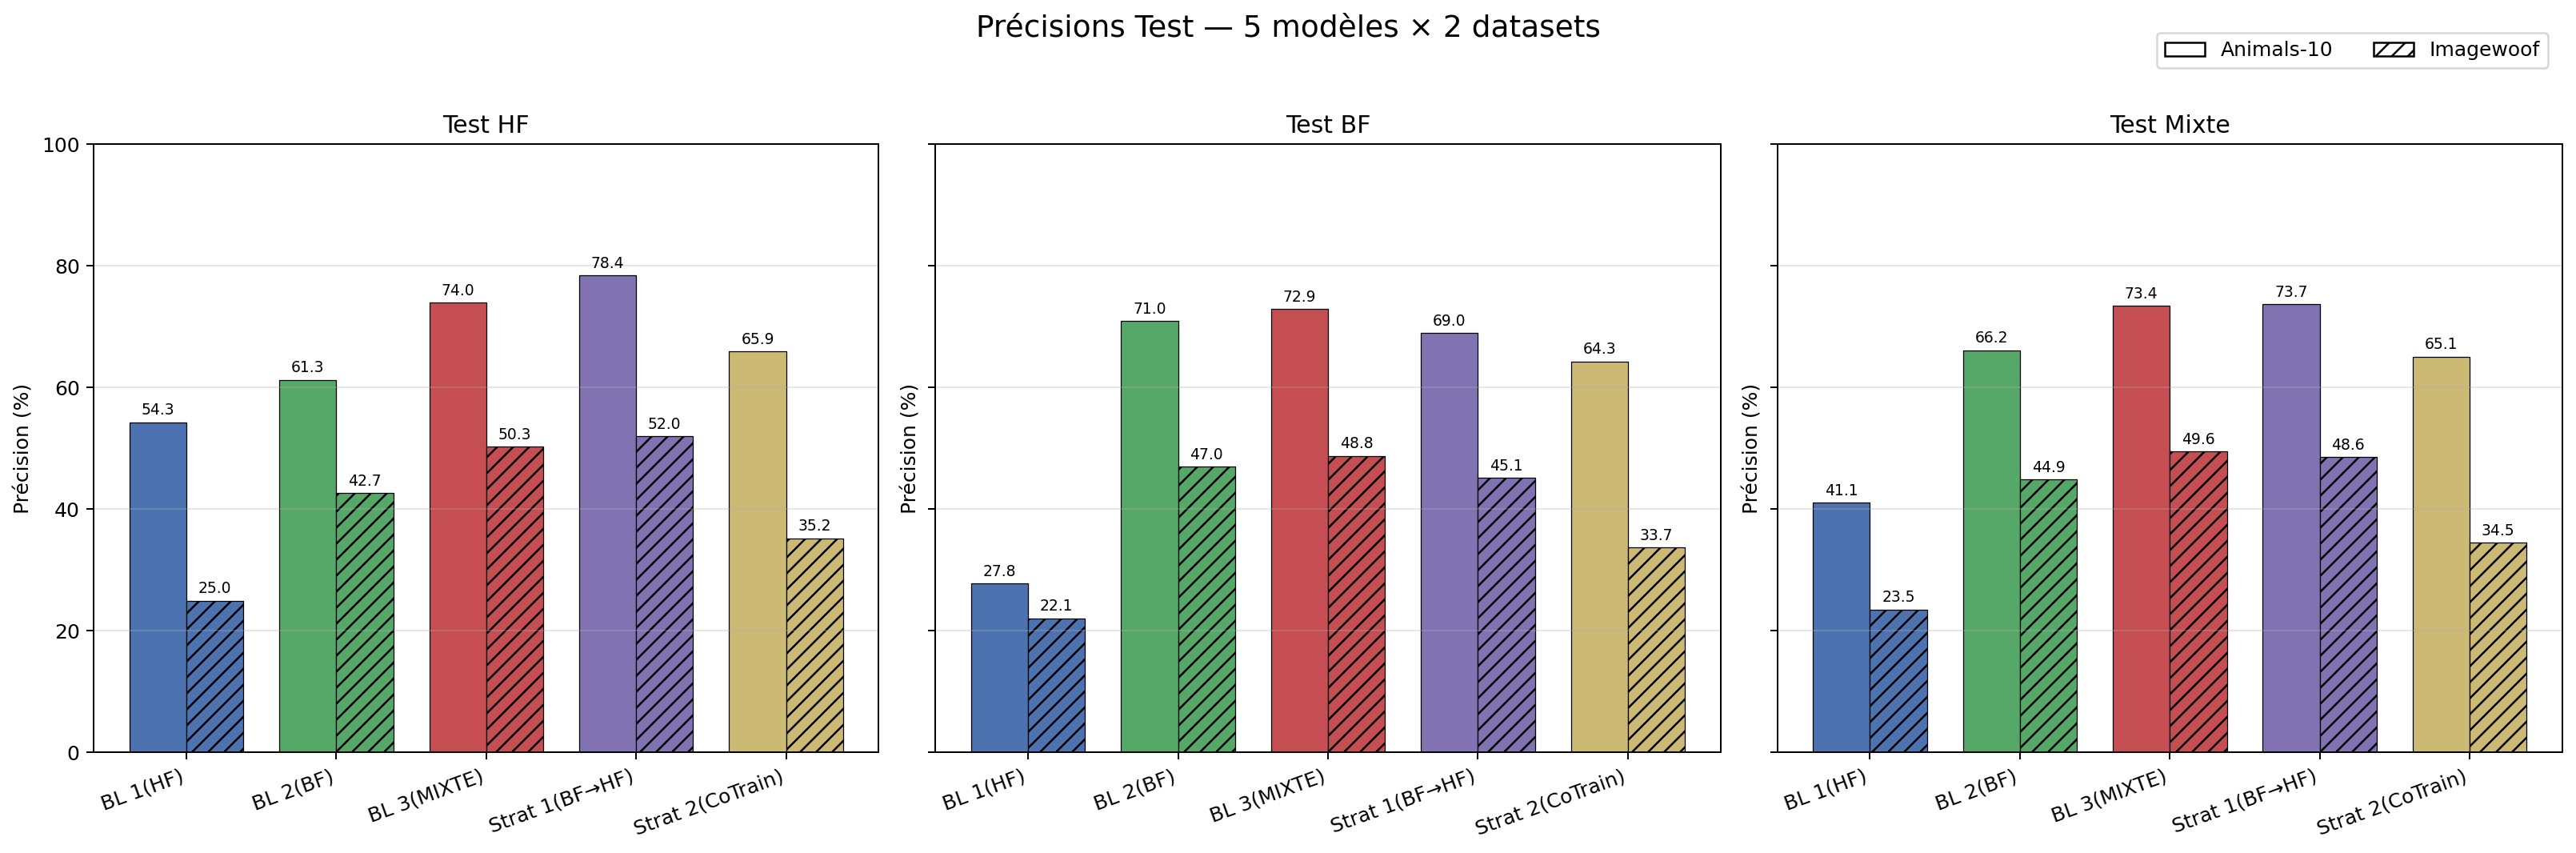

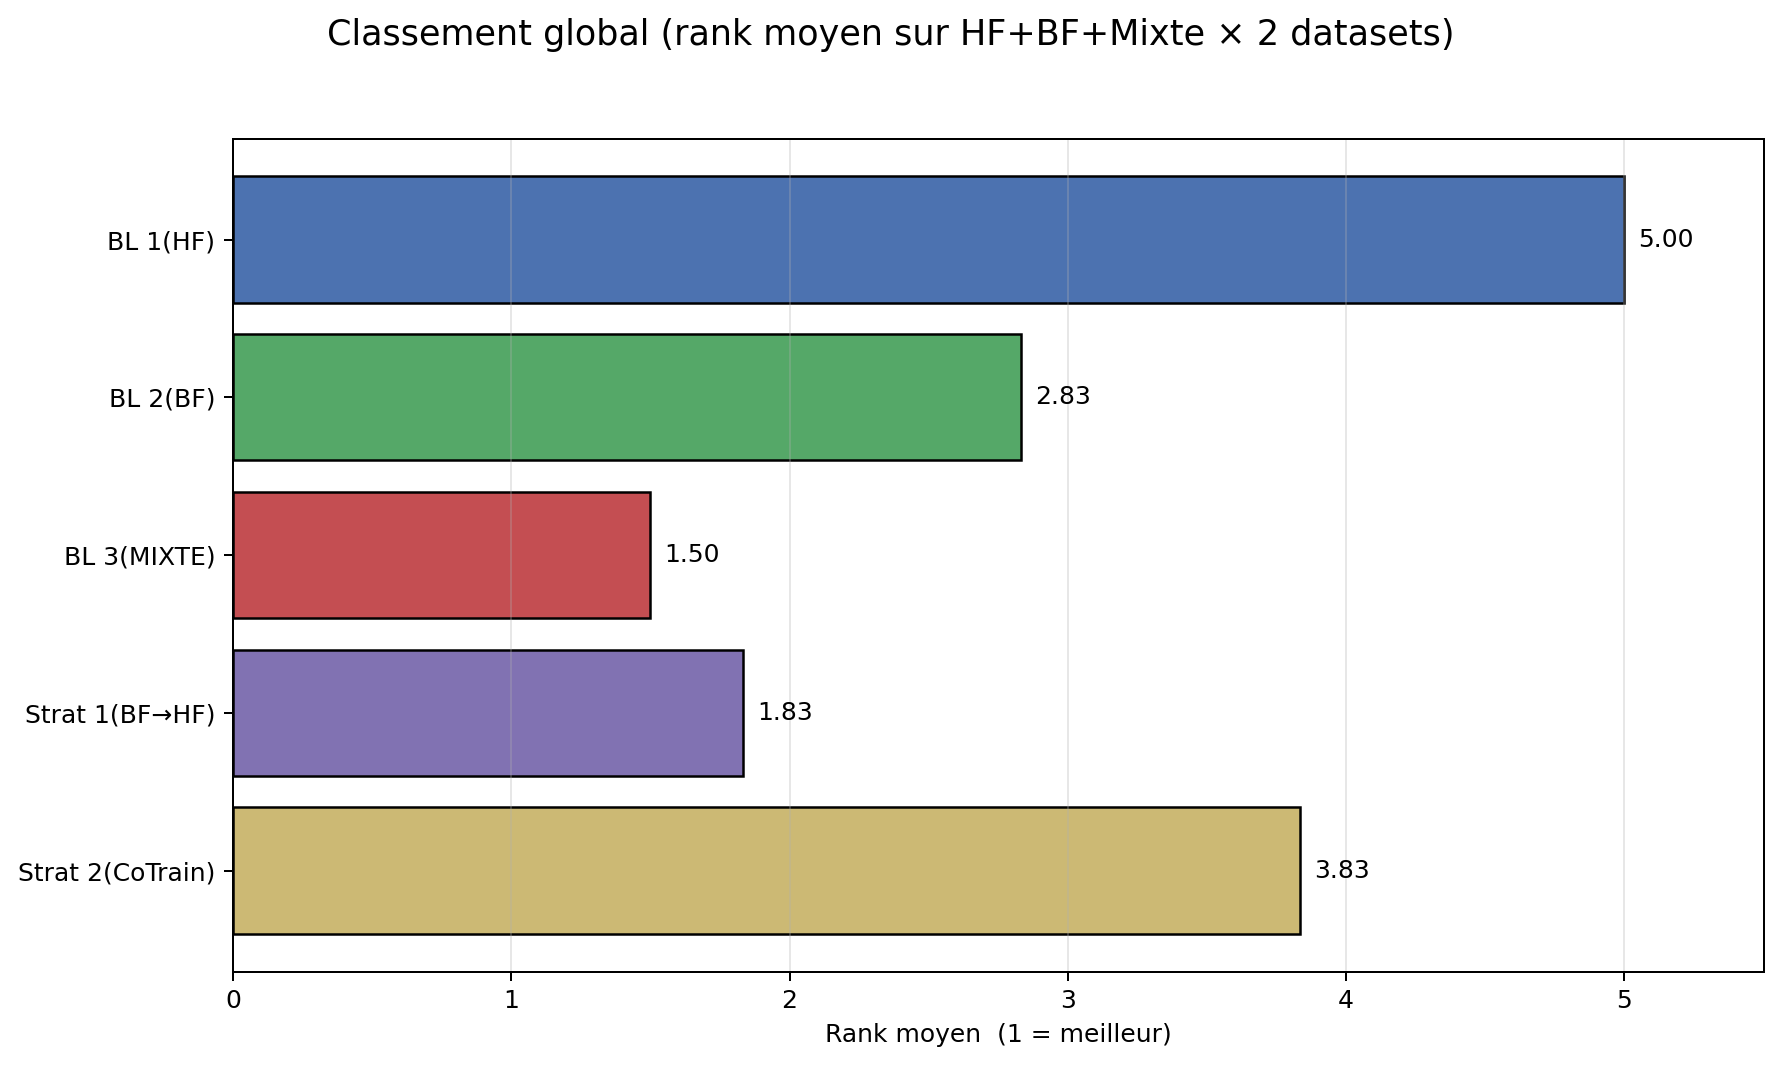

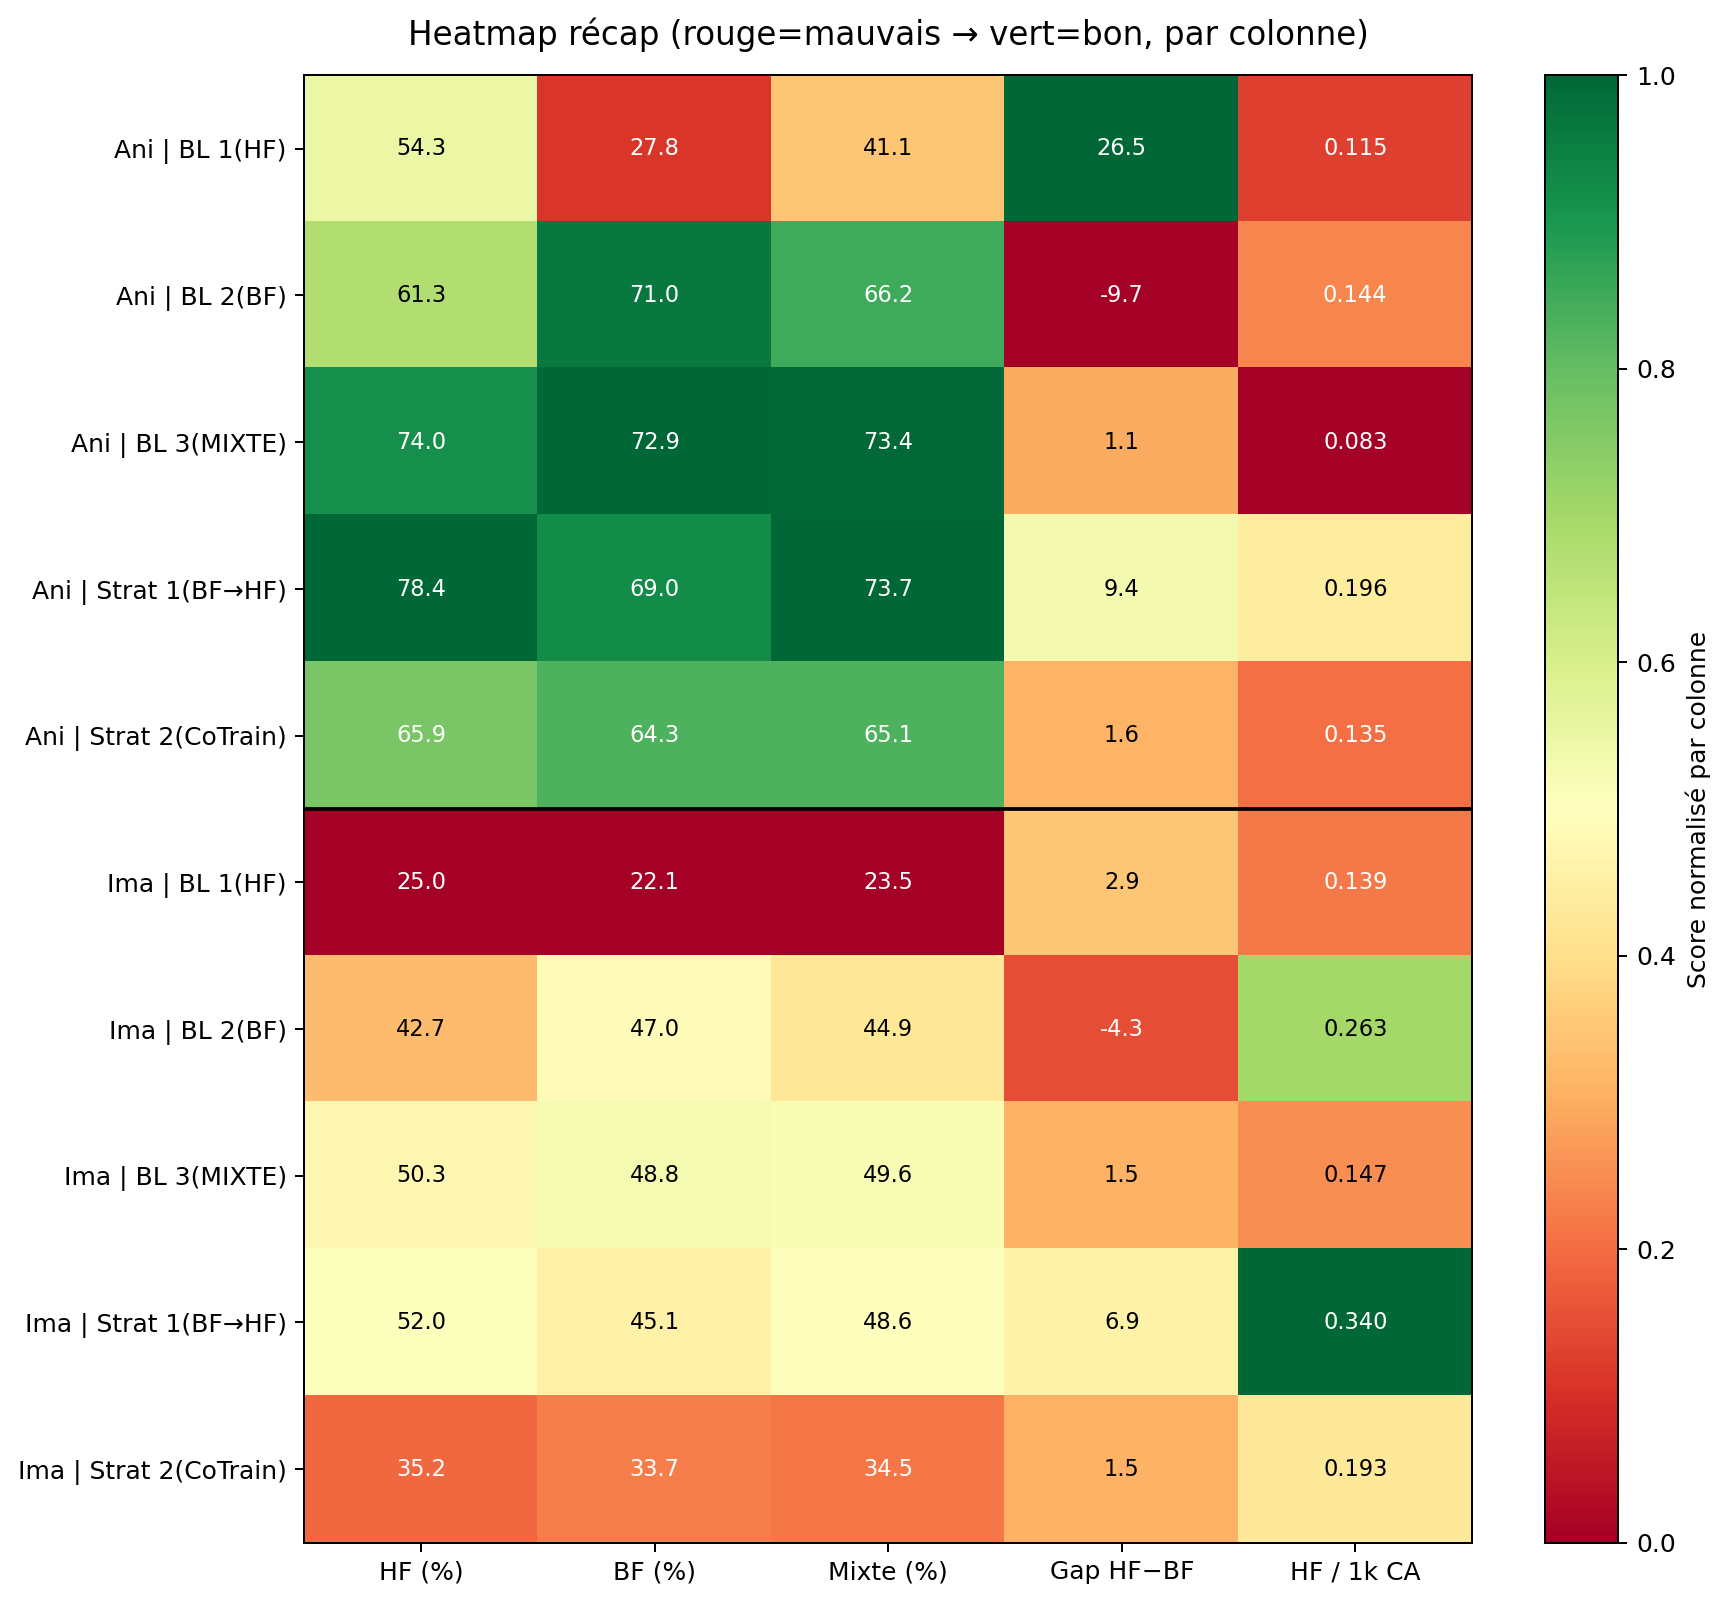

In [5]:
show(os.path.join(COMP, 'fig1_accuracy_grouped.png'))
show(os.path.join(COMP, 'fig8_global_ranking.png'))
show(os.path.join(COMP, 'fig5_heatmap_summary.png'))

Les barres groupées (couleur = modèle, hachures = dataset) montrent d'un coup d'œil
que la **hiérarchie se conserve entre Animals-10 et Imagewoof**, avec des valeurs
absolues plus basses sur Imagewoof (classification de races canines, plus difficile).
Le **classement global** (rang moyen sur HF/BF/Mixte × 2 datasets) place la
Stratégie 1 et BL3 en tête. La **heatmap** synthétise toutes les métriques.

## 5) Compromis coût / précision et temps

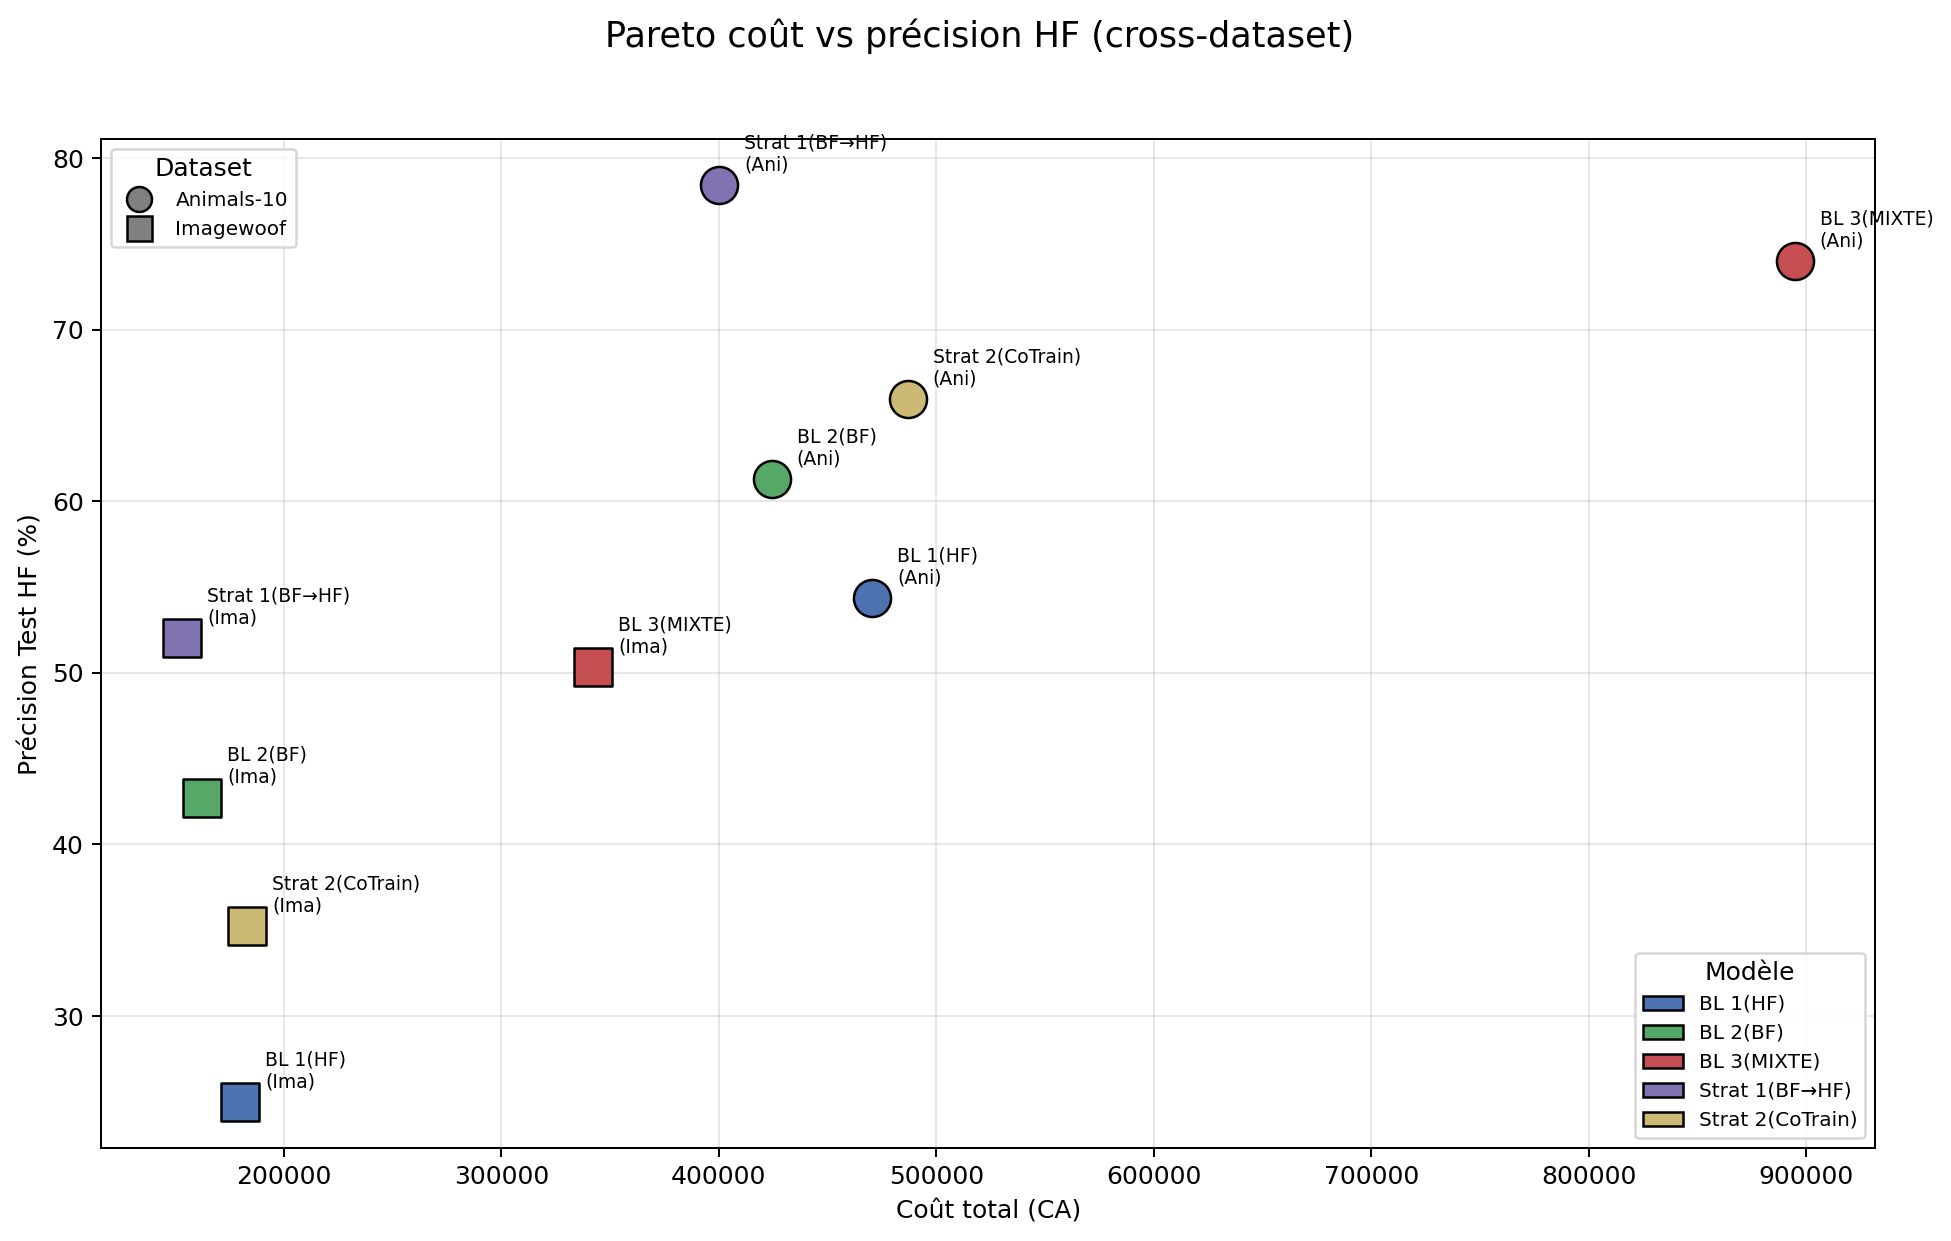

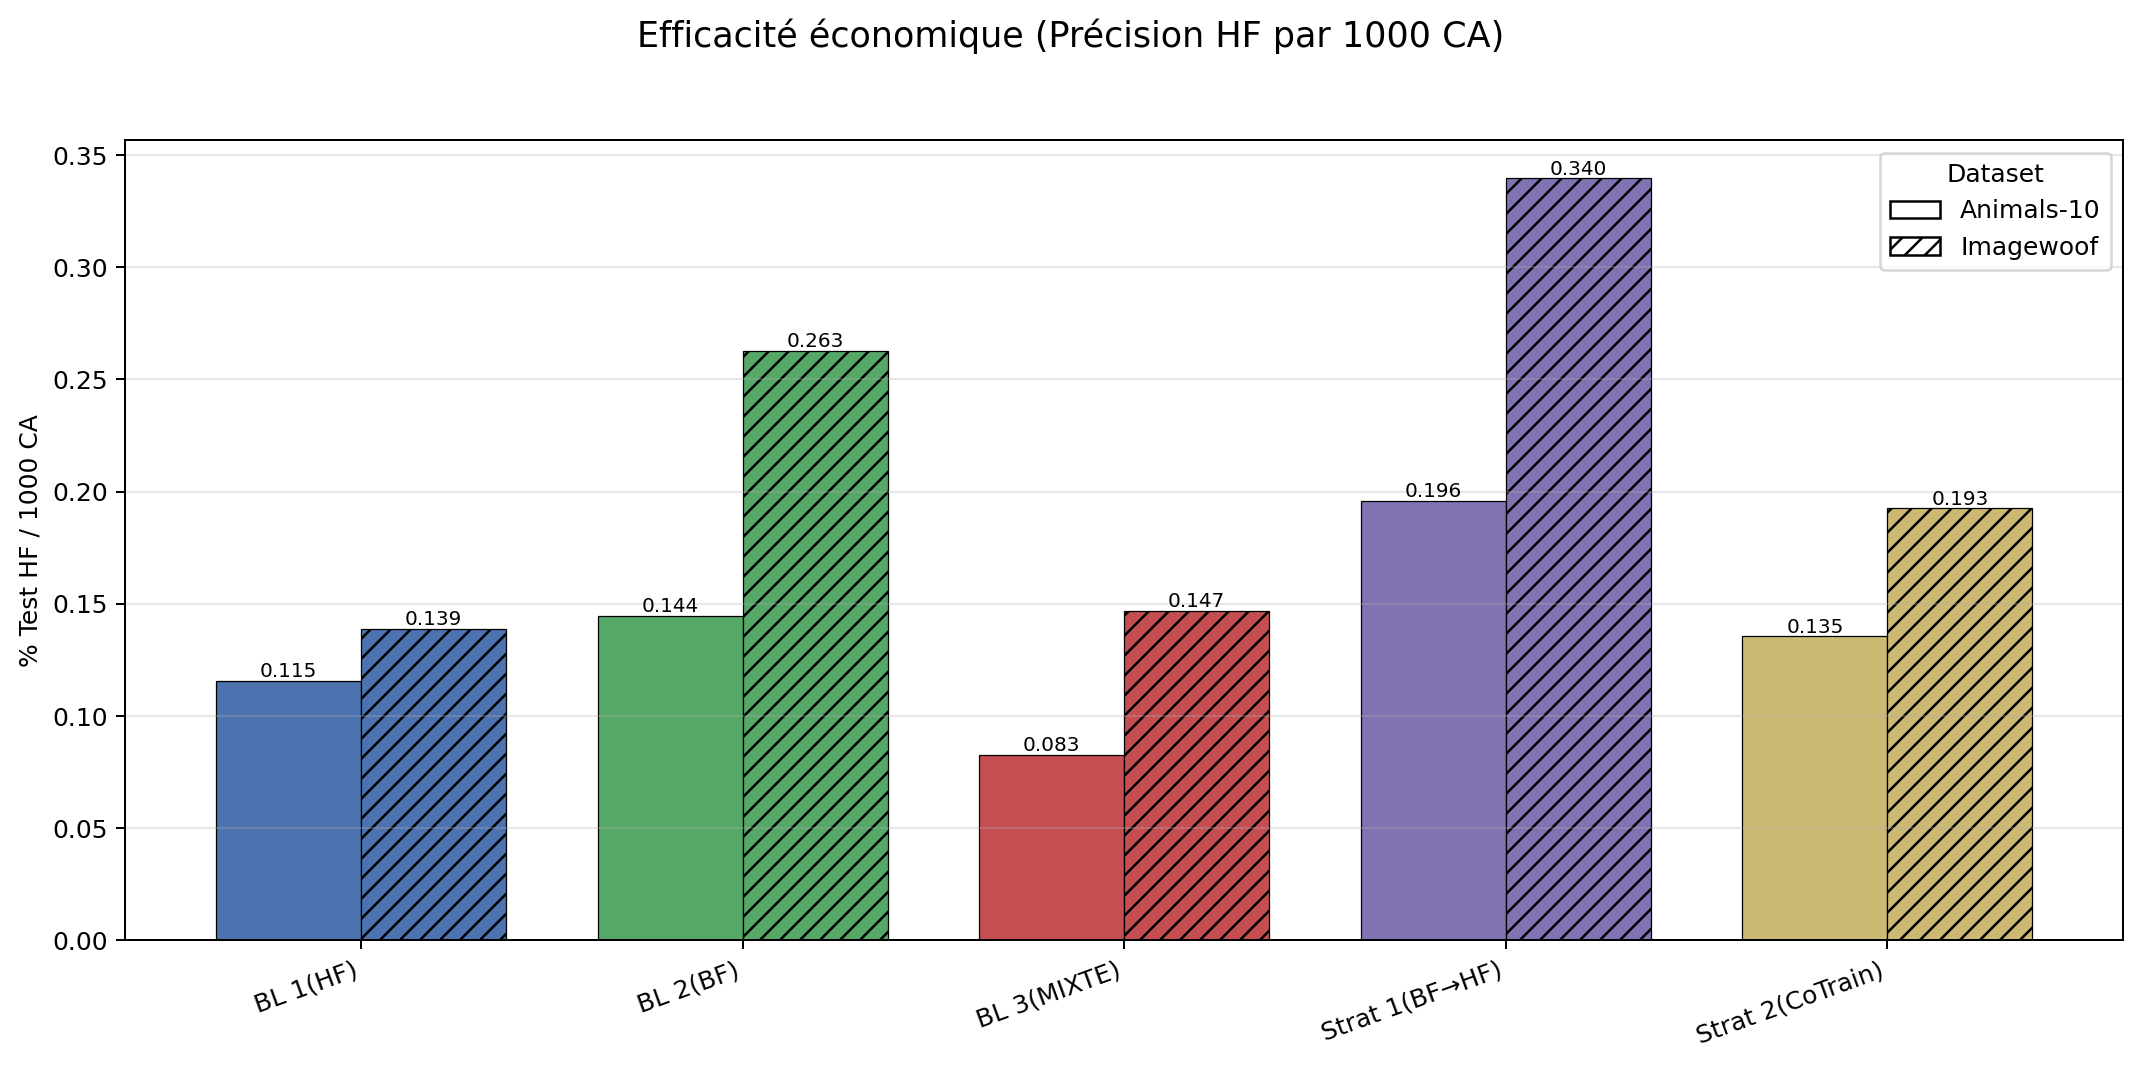

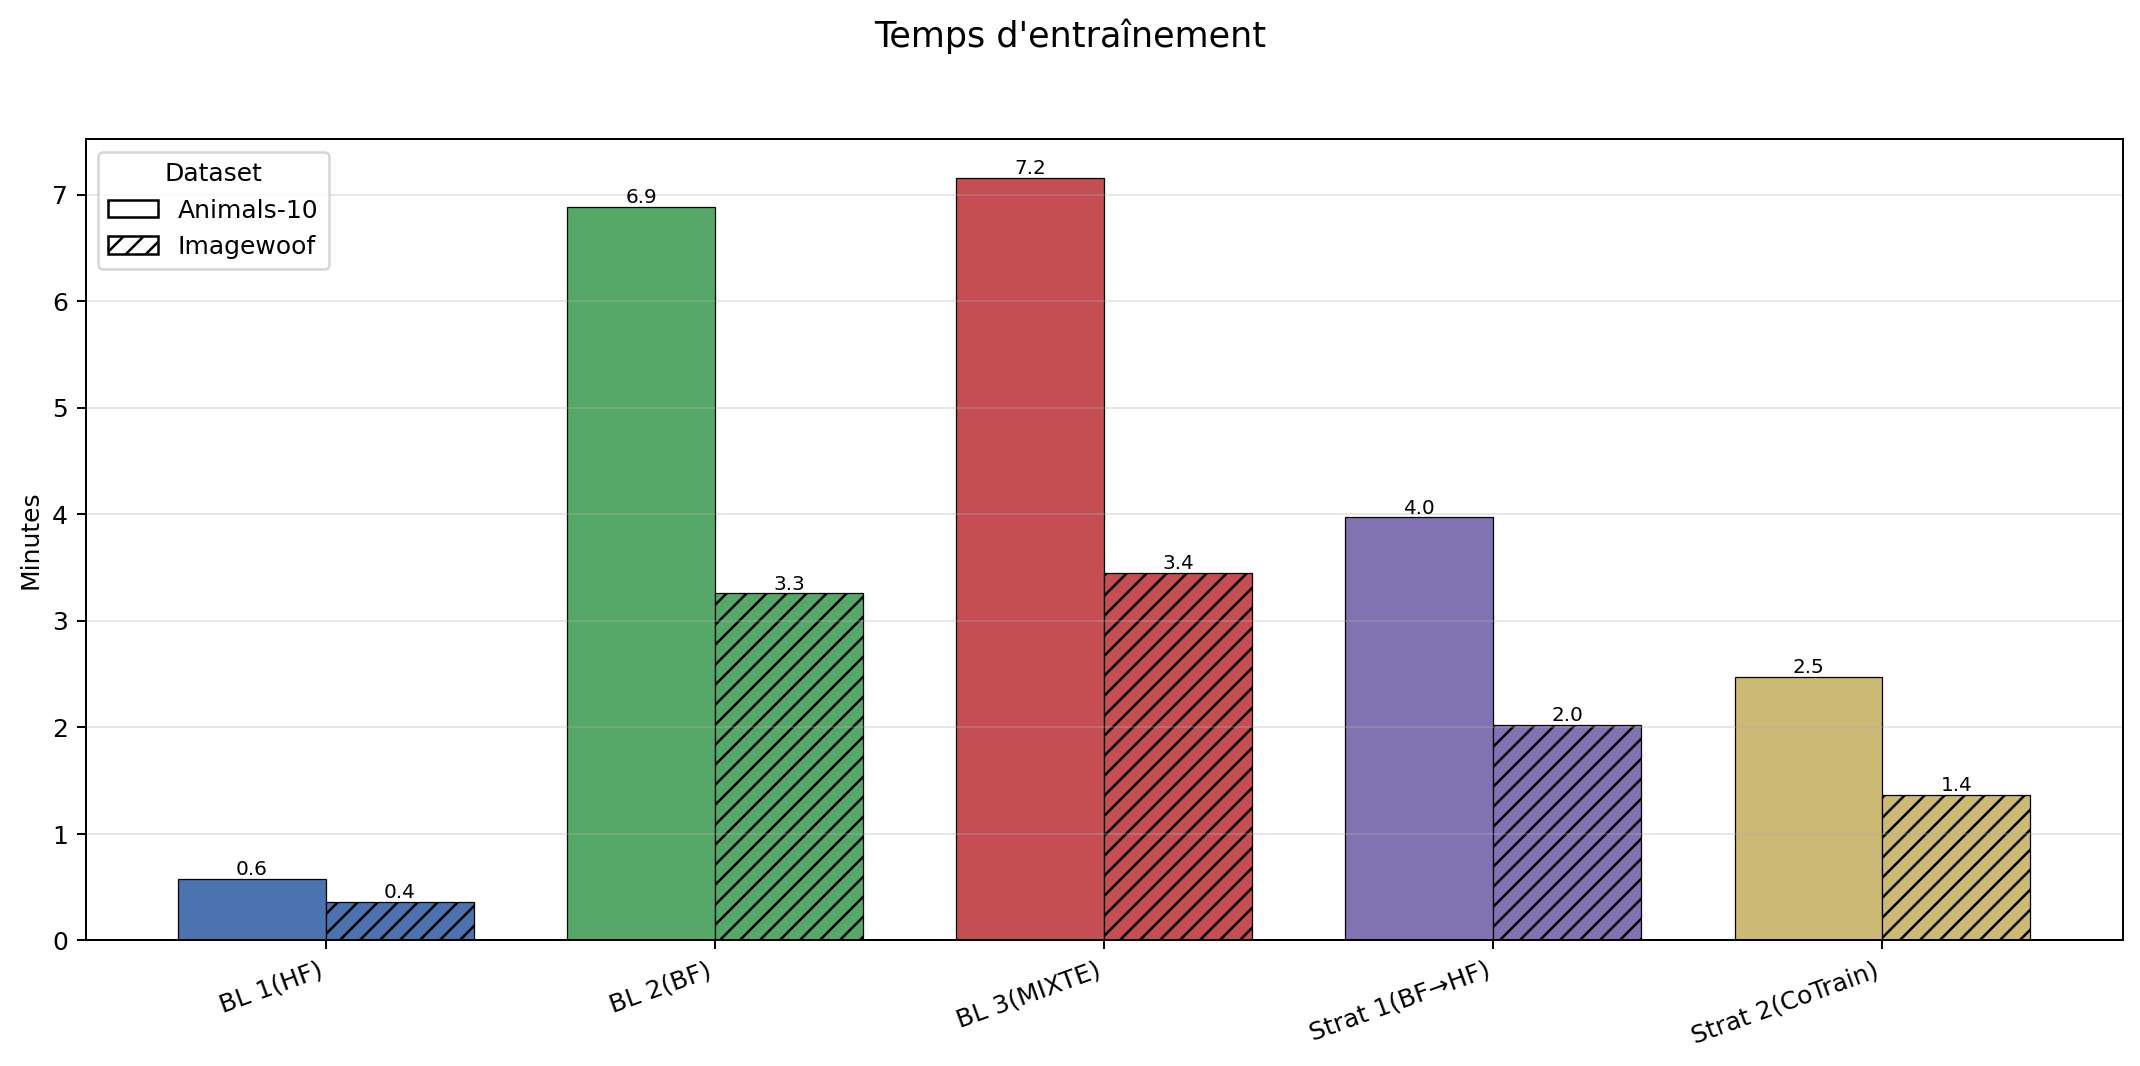

In [6]:
show(os.path.join(COMP, 'fig2_pareto_cost_vs_accuracy.png'))
show(os.path.join(COMP, 'fig4_efficiency.png'))
show(os.path.join(COMP, 'fig6_training_time.png'))

Sur la **frontière de Pareto** (coût total vs précision HF, *haut-gauche = mieux*),
la Stratégie 1 domine BL3 : meilleure précision pour un coût total moindre. La figure
d'**efficacité** (précision HF par 1000 CA) et le **temps d'entraînement** confirment
que les stratégies multi-fidélité créent leur valeur sur l'axe *coût de calcul/total*
(le coût *données* étant identique pour toutes les méthodes utilisant le pool HF+BF).

## 6) Robustesse au domaine (gap HF−BF et intensité de dégradation)

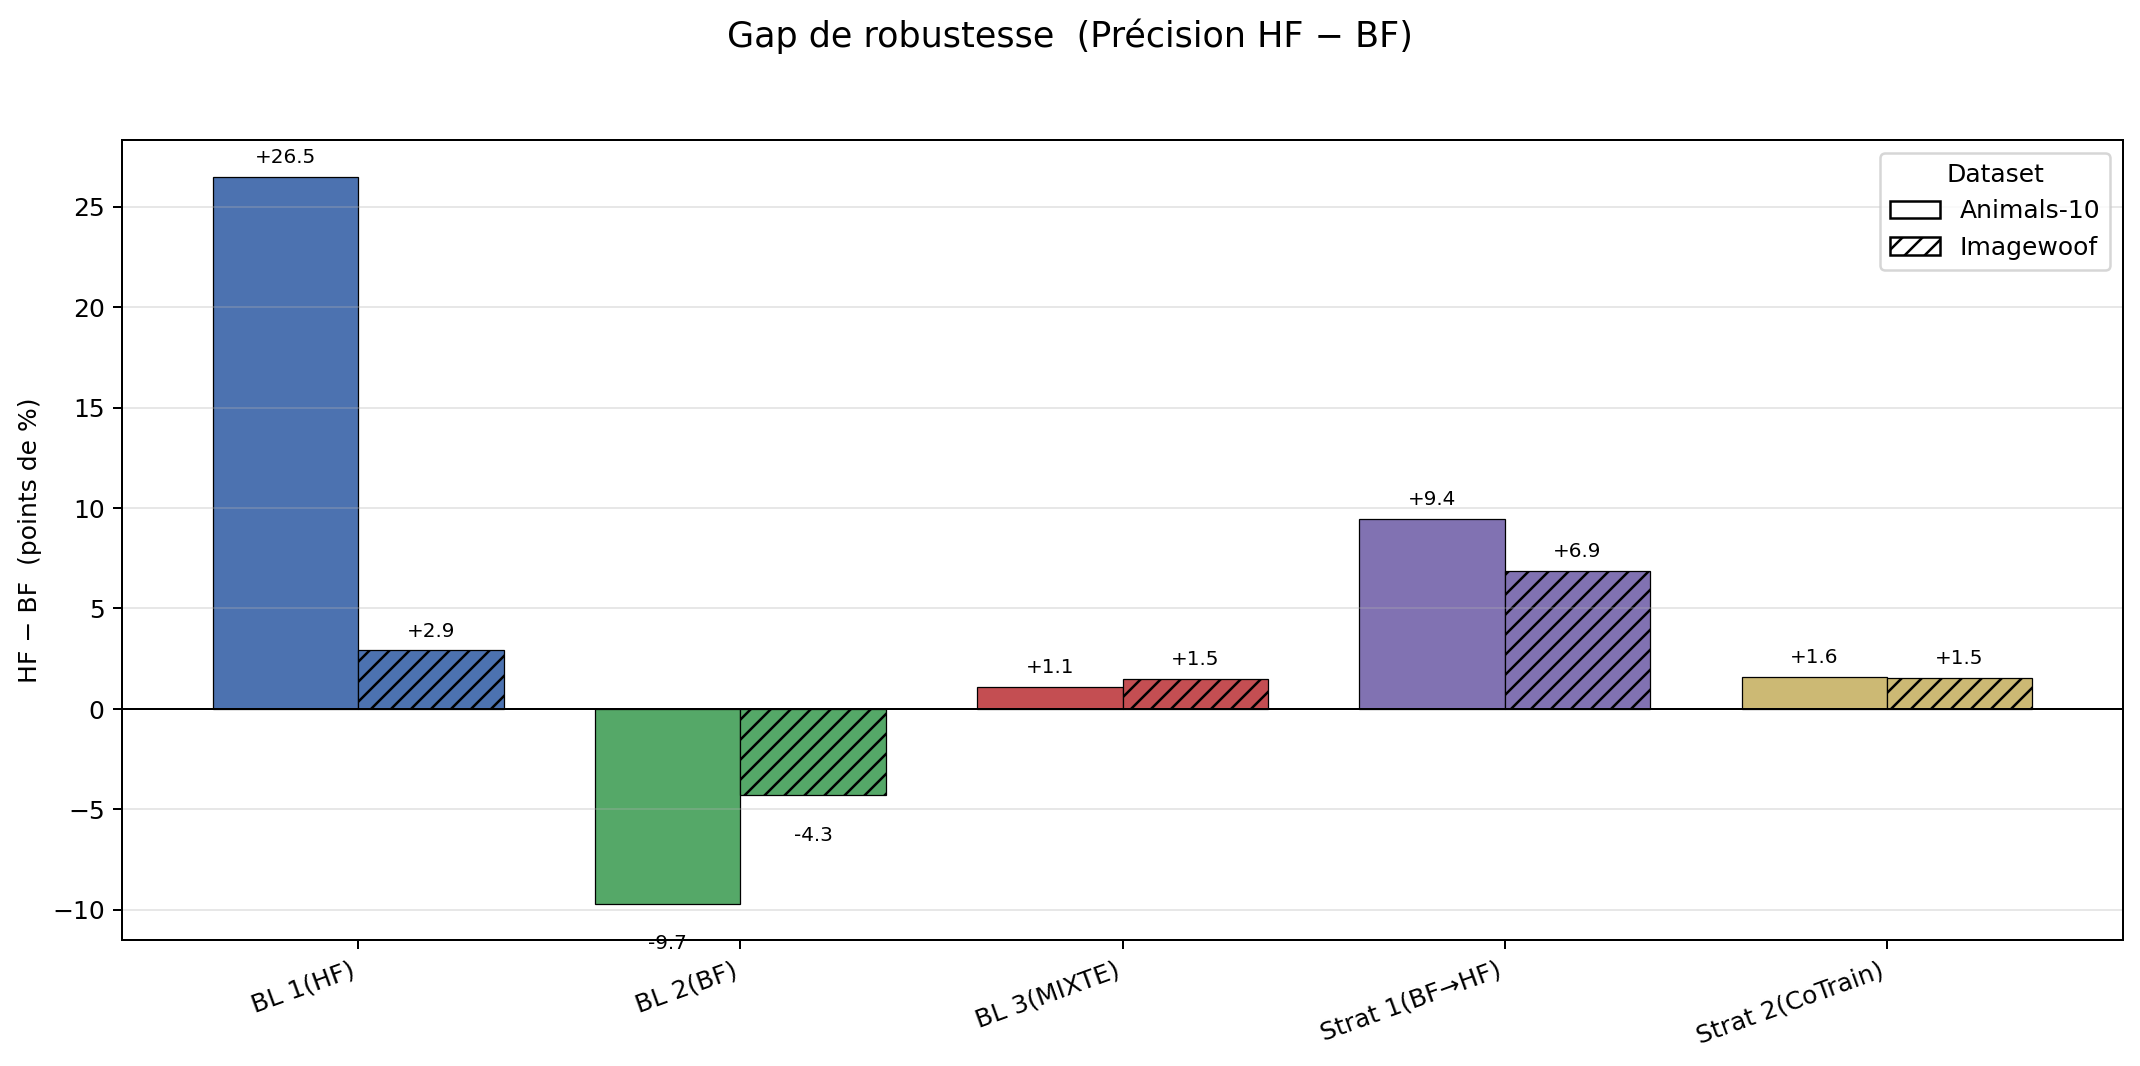

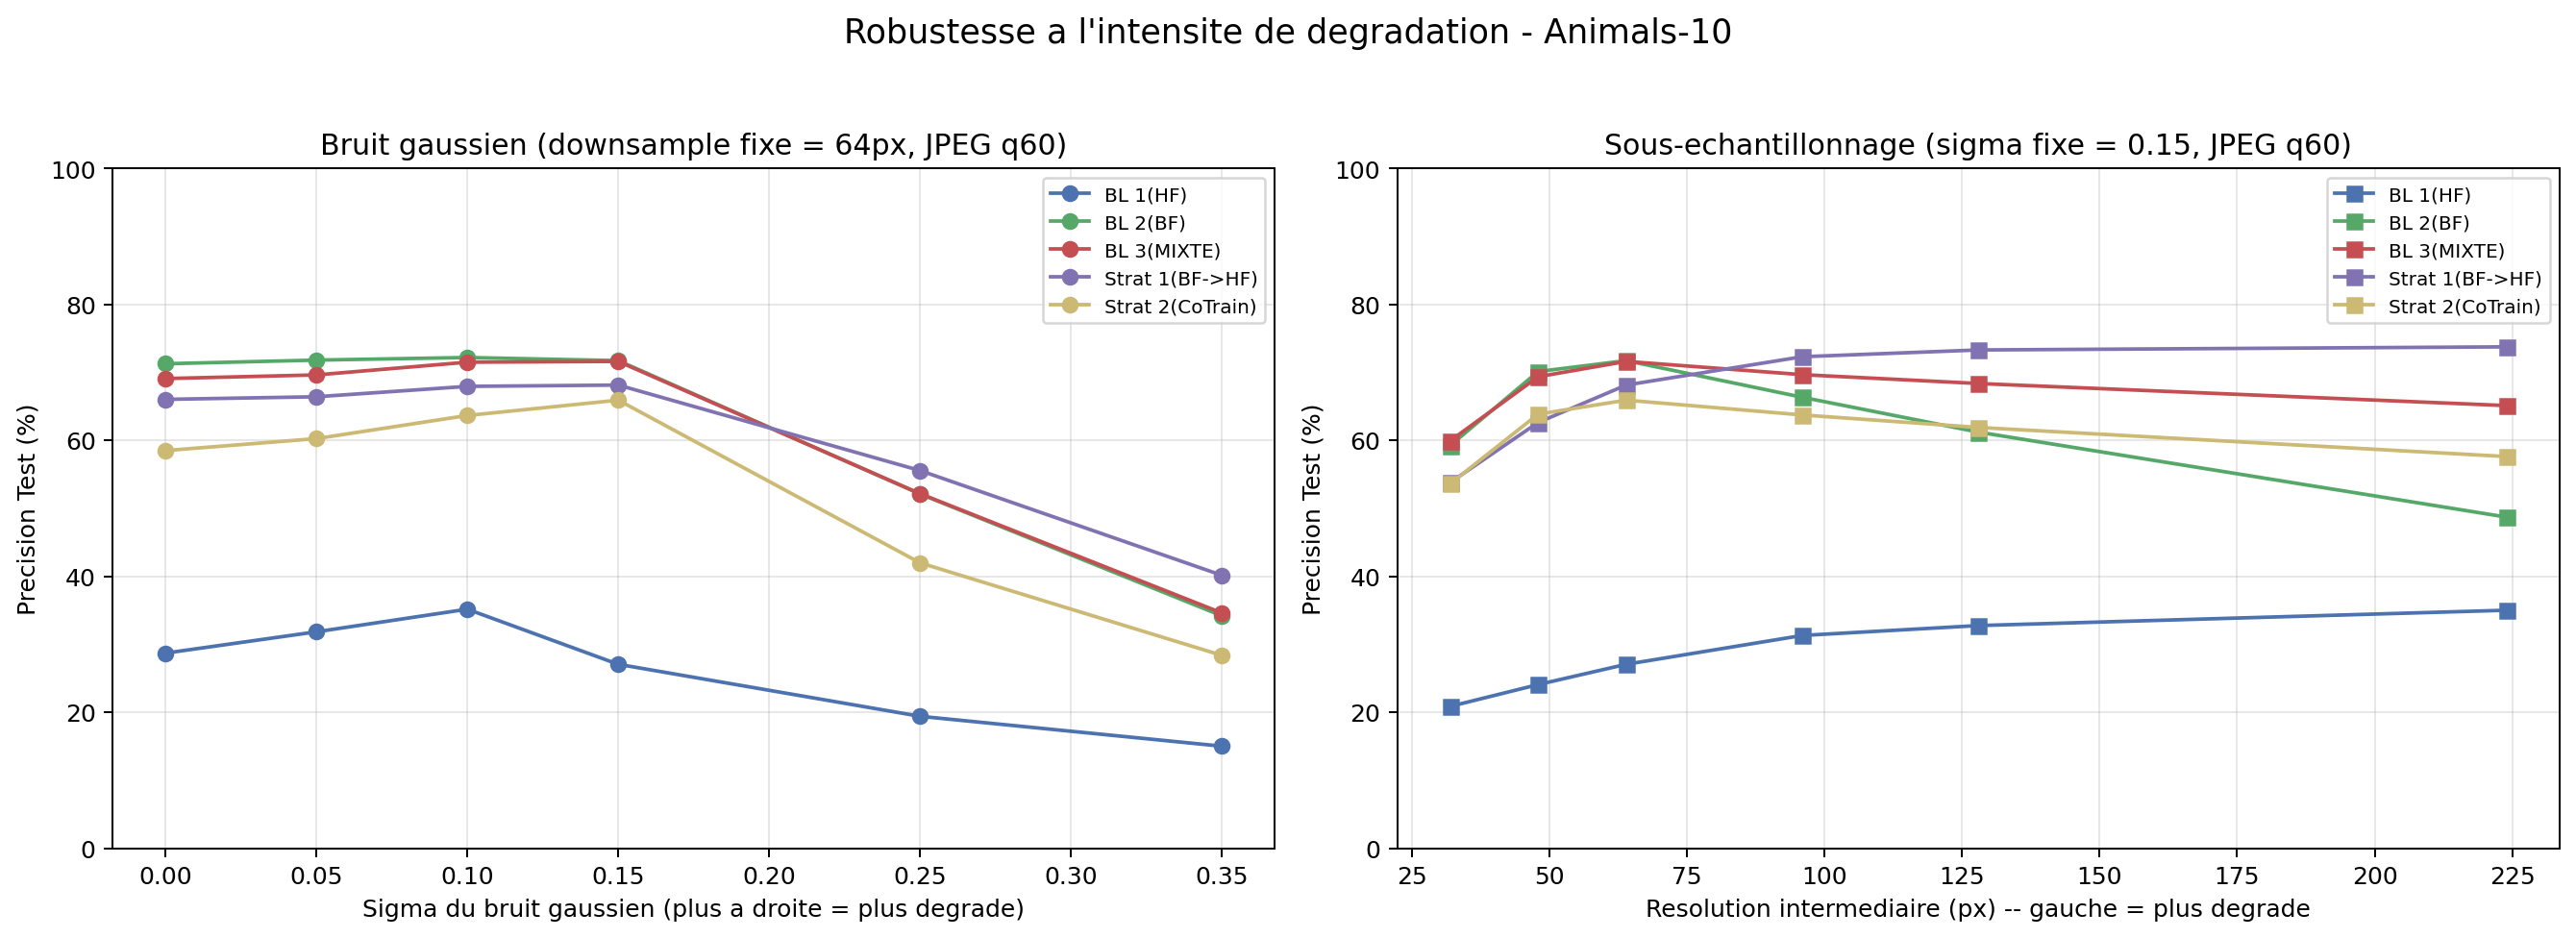

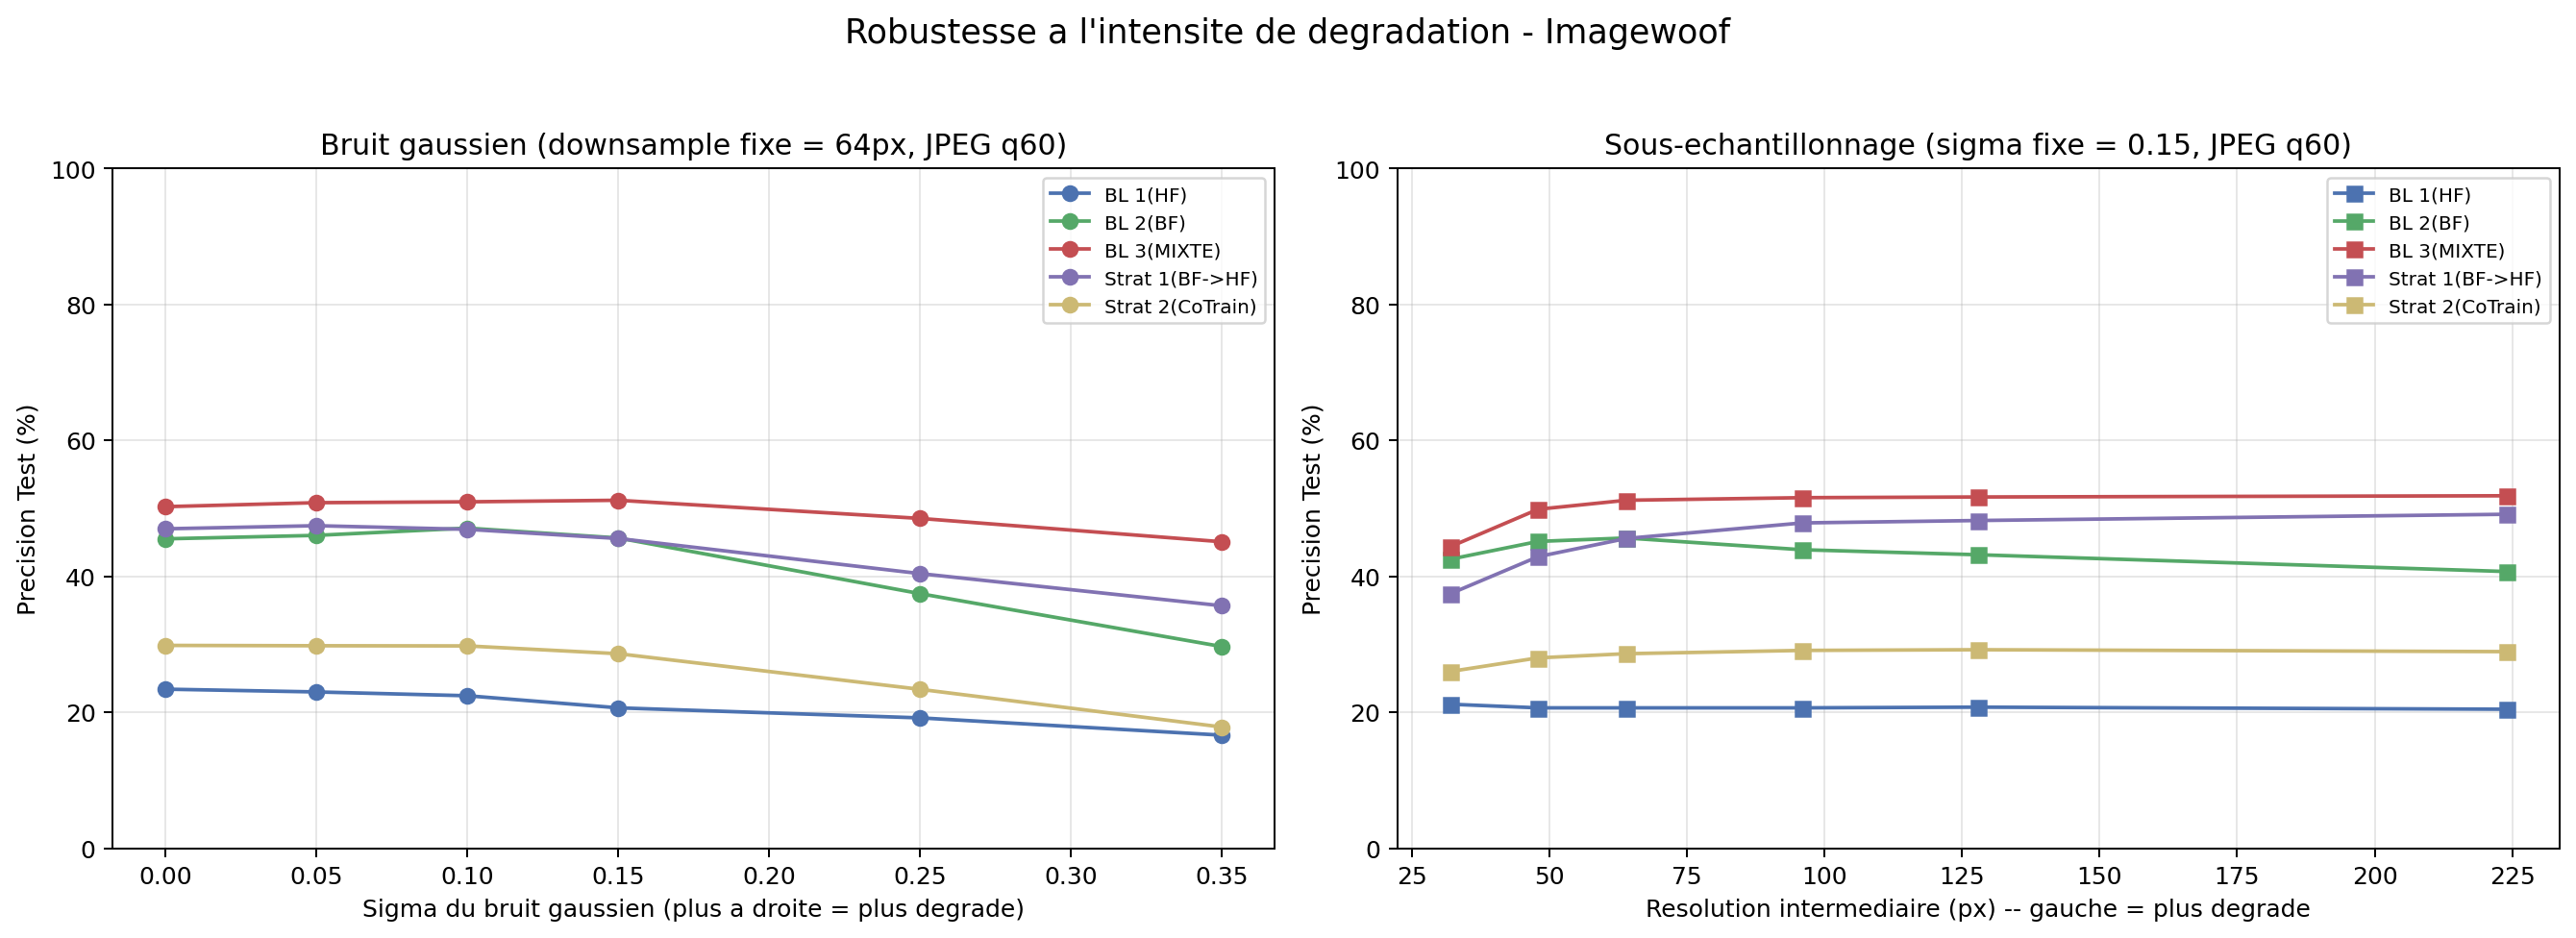

In [7]:
show(os.path.join(COMP, 'fig3_robustness_gap.png'))
show(os.path.join(COMP, 'robustness_degradation_animals.png'))
show(os.path.join(COMP, 'robustness_degradation_imagewoof.png'))

In [8]:
# Synthèse chiffrée de la robustesse (depuis robustness_degradation.json)
rob_path = os.path.join(COMP, 'robustness_degradation.json')
if os.path.exists(rob_path):
    rob = json.load(open(rob_path, encoding='utf-8'))
    for ds, r in rob.items():
        print(f"=== {ds} (downsample fixé à {r['sigma_fixed_downscale']}px) ===")
        sig = r['sigma_levels']
        for m, info in r['models'].items():
            a0, a1 = info['sigma_acc'][0], info['sigma_acc'][-1]
            print(f"  {m:18} bruit σ={sig[0]}→{sig[-1]} : {a0:5.1f}% → {a1:5.1f}% "
                  f"(perte {a0-a1:5.1f} pts)")
        print()
else:
    print('robustness_degradation.json absent')

=== Animals-10 (downsample fixé à 64px) ===
  BL 1(HF)           bruit σ=0.0→0.35 :  28.7% →  15.0% (perte  13.7 pts)
  BL 2(BF)           bruit σ=0.0→0.35 :  71.3% →  34.2% (perte  37.1 pts)
  BL 3(MIXTE)        bruit σ=0.0→0.35 :  69.1% →  34.6% (perte  34.5 pts)
  Strat 1(BF->HF)    bruit σ=0.0→0.35 :  66.0% →  40.1% (perte  25.9 pts)
  Strat 2(CoTrain)   bruit σ=0.0→0.35 :  58.5% →  28.3% (perte  30.1 pts)

=== Imagewoof (downsample fixé à 64px) ===
  BL 1(HF)           bruit σ=0.0→0.35 :  23.4% →  16.6% (perte   6.8 pts)
  BL 2(BF)           bruit σ=0.0→0.35 :  45.5% →  29.7% (perte  15.9 pts)
  BL 3(MIXTE)        bruit σ=0.0→0.35 :  50.2% →  45.1% (perte   5.2 pts)
  Strat 1(BF->HF)    bruit σ=0.0→0.35 :  47.0% →  35.7% (perte  11.3 pts)
  Strat 2(CoTrain)   bruit σ=0.0→0.35 :  29.8% →  17.8% (perte  12.0 pts)



Un **gap HF−BF** proche de 0 = modèle robuste (généralise au domaine dégradé) ;
un gap positif élevé = sur-spécialisation sur le domaine propre. Les **courbes
d'intensité** montrent que **BL1 (HF seulement) est la plus fragile** (chute rapide
dès qu'on ajoute bruit/sous-échantillonnage), tandis que les modèles ayant vu du BF
(BL2, BL3, Stratégie 1) restent robustes jusqu'à des dégradations modérées et ne
s'effondrent qu'aux intensités extrêmes (σ élevé).

## 7) Sensibilité au ratio de coût HF:BF

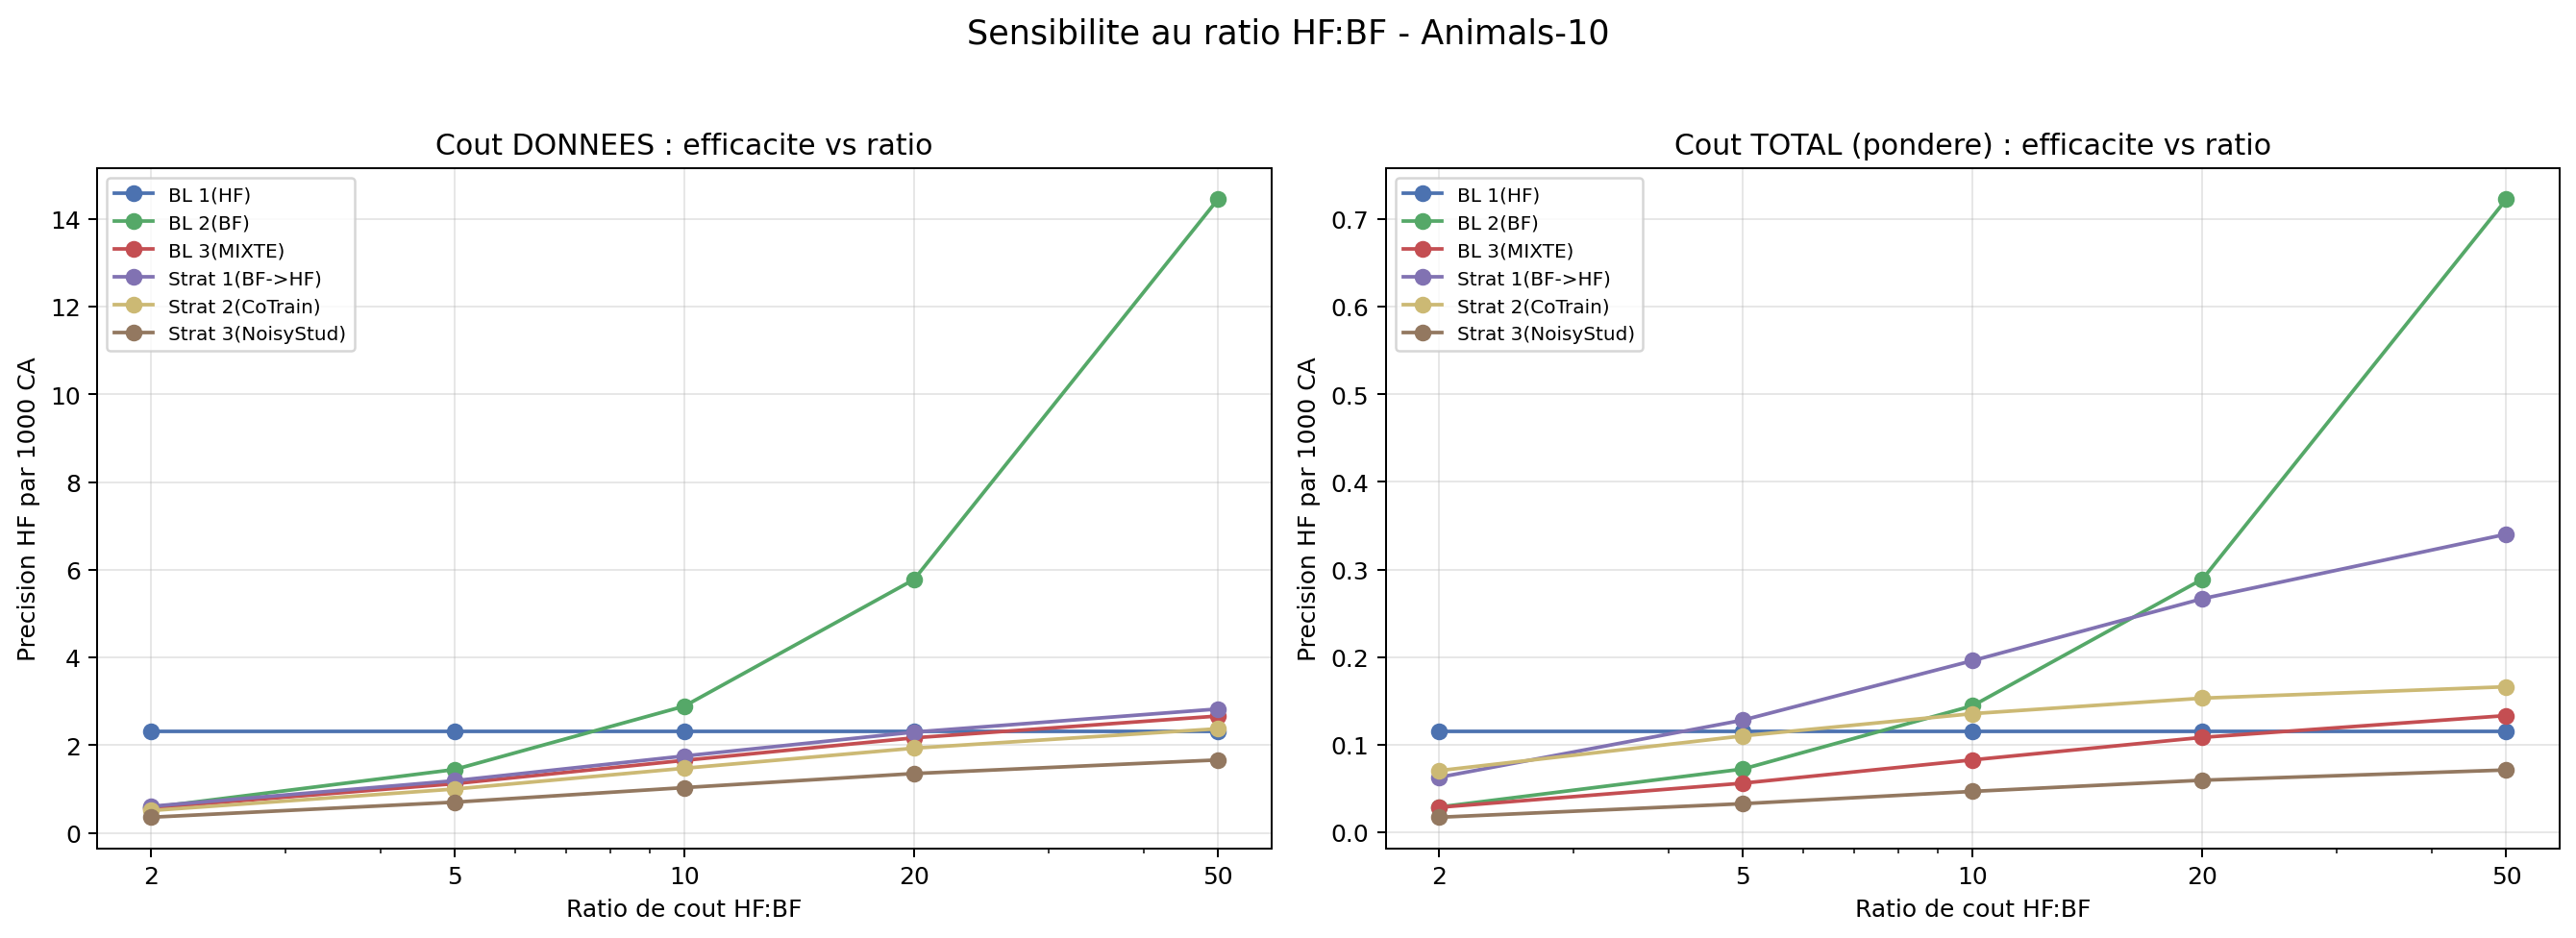

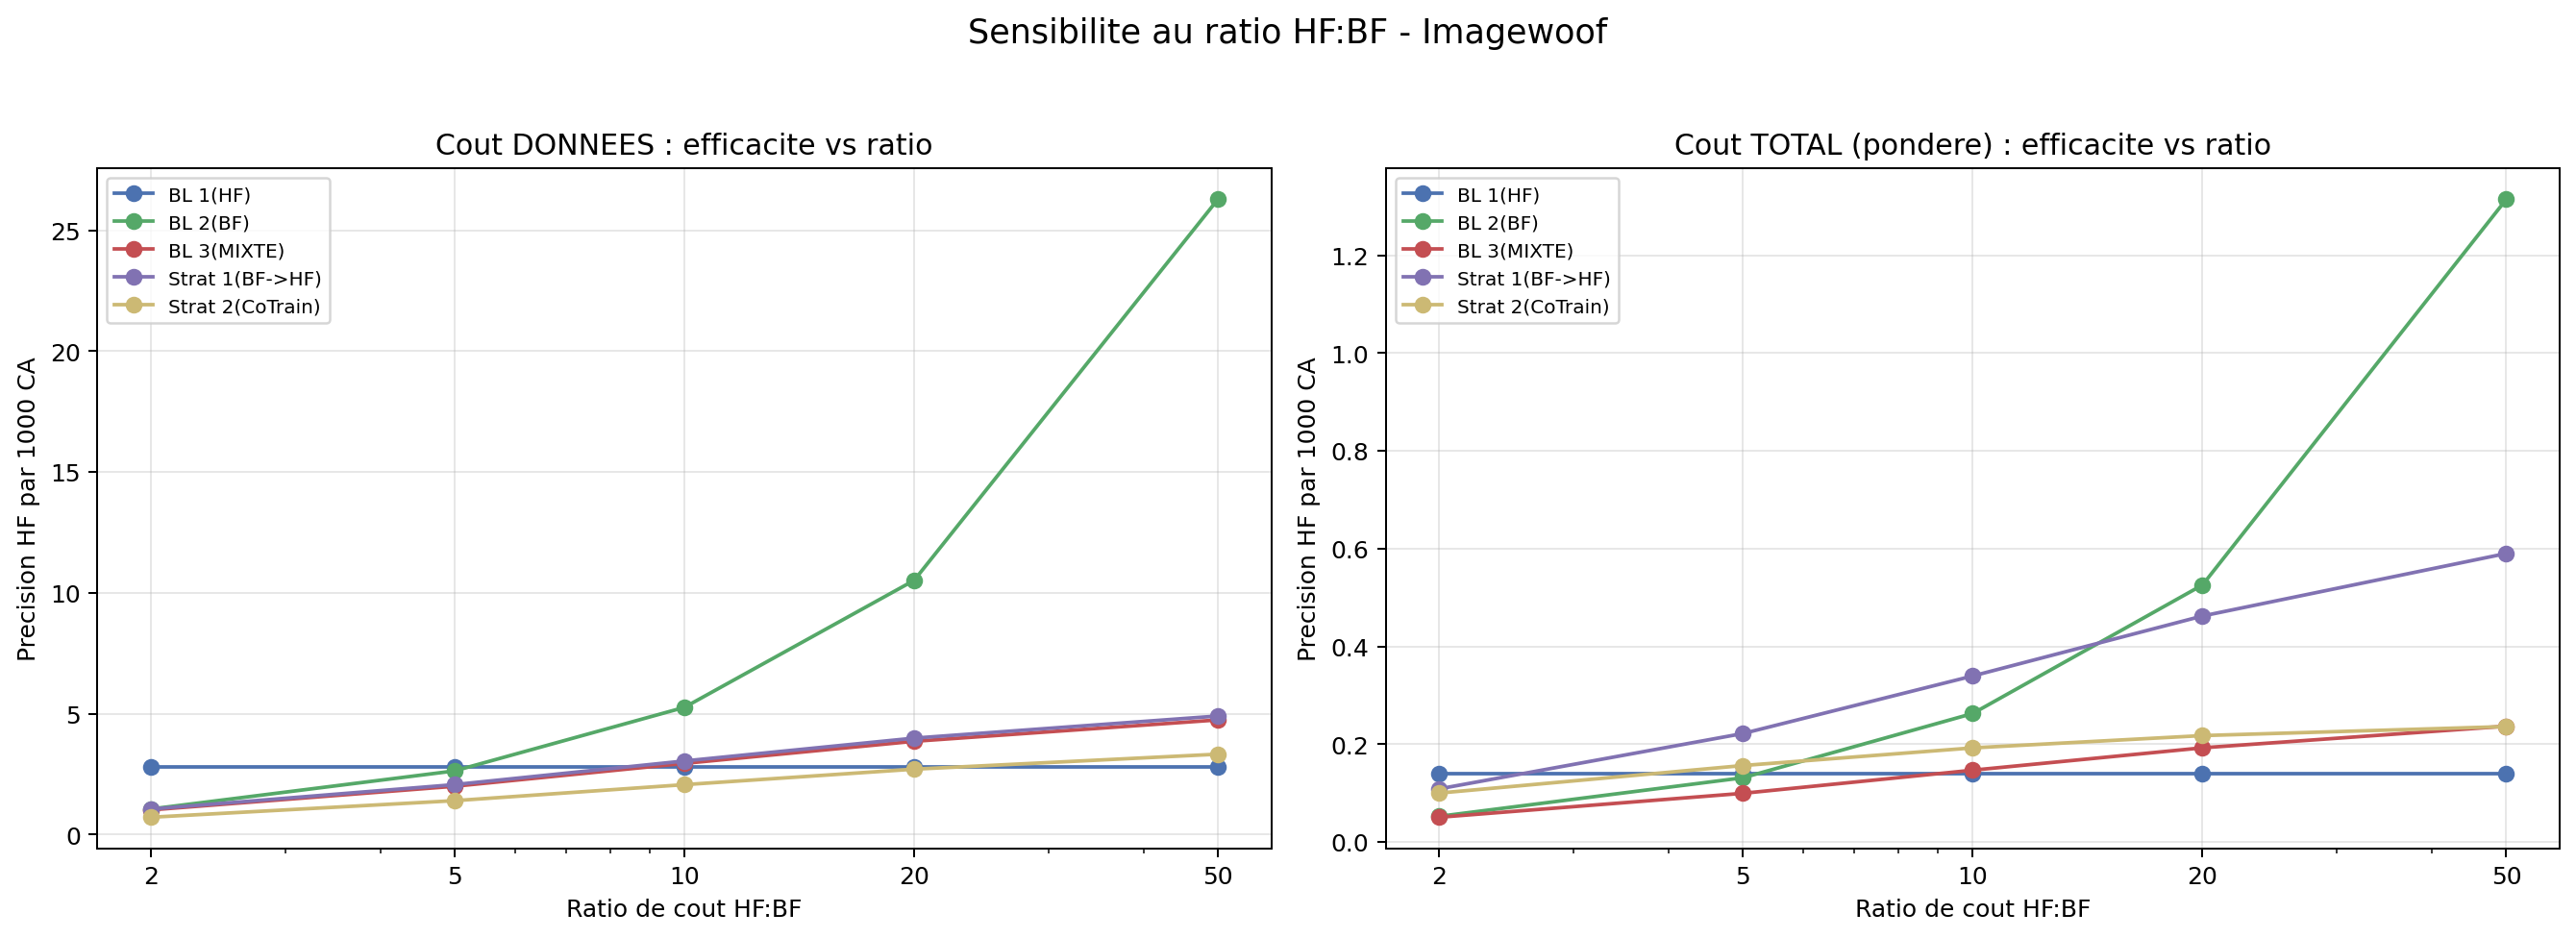

In [9]:
show(os.path.join(COMP, 'cost_ratio_sensitivity_animals.png'))
show(os.path.join(COMP, 'cost_ratio_sensitivity_imagewoof.png'))

In [10]:
# Robustesse des conclusions au ratio (depuis cost_ratio_sensitivity.json)
cr_path = os.path.join(COMP, 'cost_ratio_sensitivity.json')
if os.path.exists(cr_path):
    cr = json.load(open(cr_path, encoding='utf-8'))
    for ds, c in cr.items():
        print(f"=== {ds} : meilleur modèle (efficacité) par ratio ===")
        for kind in ('data', 'total'):
            rob = c['robustness'][kind]
            label = 'coût données' if kind == 'data' else 'coût total'
            bp = rob['best_per_ratio']
            verdict = 'ROBUSTE' if rob['robust'] else 'SENSIBLE au ratio'
            print(f"  [{label:12}] {verdict} : " +
                  ' | '.join([f"R={r}:{bp[r]}" for r in bp]))
        print()
else:
    print('cost_ratio_sensitivity.json absent')

=== Animals-10 : meilleur modèle (efficacité) par ratio ===
  [coût données] SENSIBLE au ratio : R=2:BL 1(HF) | R=5:BL 1(HF) | R=10:BL 2(BF) | R=20:BL 2(BF) | R=50:BL 2(BF)
  [coût total  ] SENSIBLE au ratio : R=2:BL 1(HF) | R=5:Strat 1(BF->HF) | R=10:Strat 1(BF->HF) | R=20:BL 2(BF) | R=50:BL 2(BF)

=== Imagewoof : meilleur modèle (efficacité) par ratio ===
  [coût données] SENSIBLE au ratio : R=2:BL 1(HF) | R=5:BL 1(HF) | R=10:BL 2(BF) | R=20:BL 2(BF) | R=50:BL 2(BF)
  [coût total  ] SENSIBLE au ratio : R=2:BL 1(HF) | R=5:Strat 1(BF->HF) | R=10:Strat 1(BF->HF) | R=20:BL 2(BF) | R=50:BL 2(BF)



**Nuance importante.** Le « meilleur » modèle au sens de l'**efficacité**
(précision HF par CA dépensé) **dépend du ratio HF:BF** (conclusion *non robuste*) :
à faible ratio (HF peu coûteuse), les modèles riches en HF sont les plus efficaces ;
à fort ratio (HF très coûteuse), les modèles riches en BF bon marché le deviennent ;
la Stratégie 1 domine dans la zone intermédiaire (≈ 5:1–10:1) sur le coût total.

En revanche, sur la **précision HF absolue**, la Stratégie 1 reste la meilleure
quel que soit le ratio. Le choix dépend donc de l'objectif : **maximiser la précision
HF → Stratégie 1** ; **maximiser l'efficacité quand la donnée HF est extrêmement
chère → solutions riches en BF**.

## 8) Courbes d'entraînement (seed canonique)

**Animals-10**

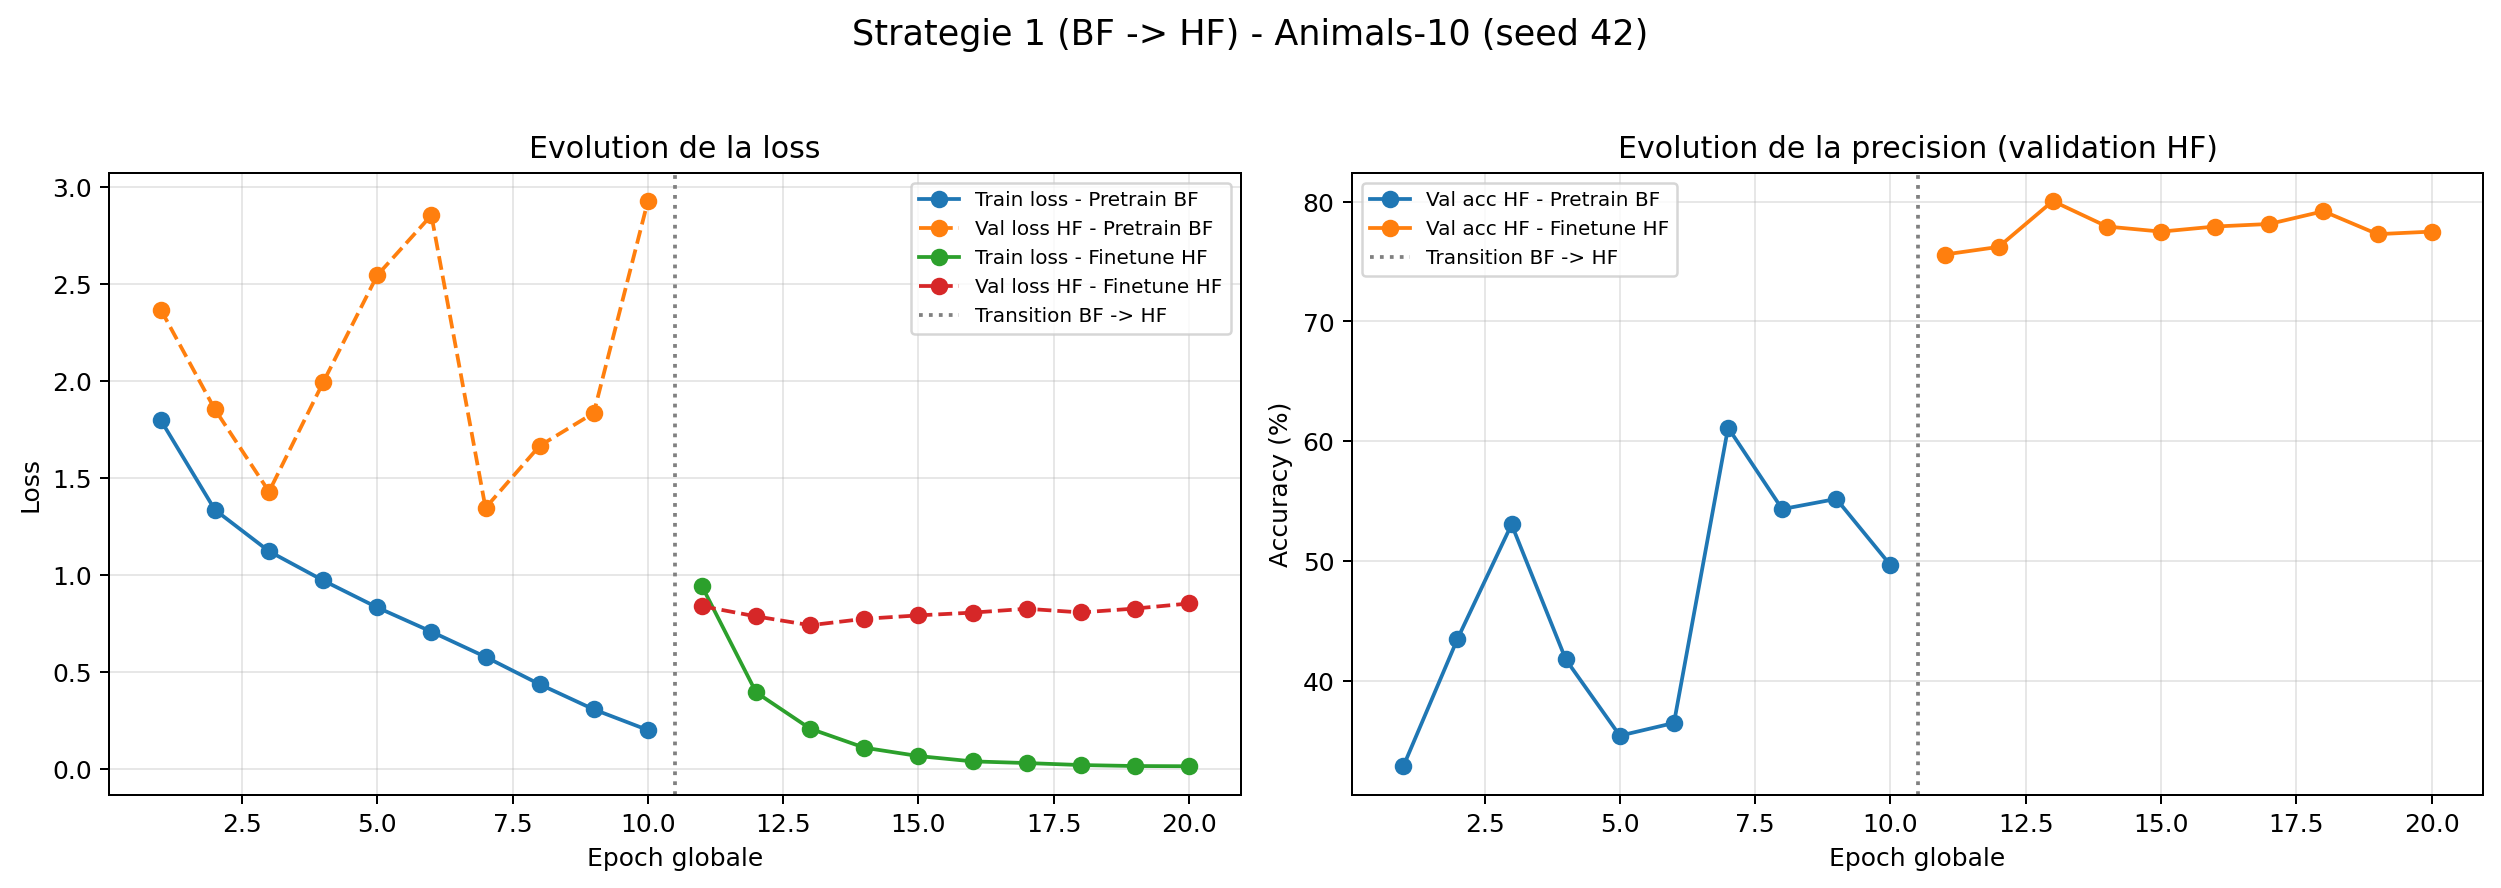

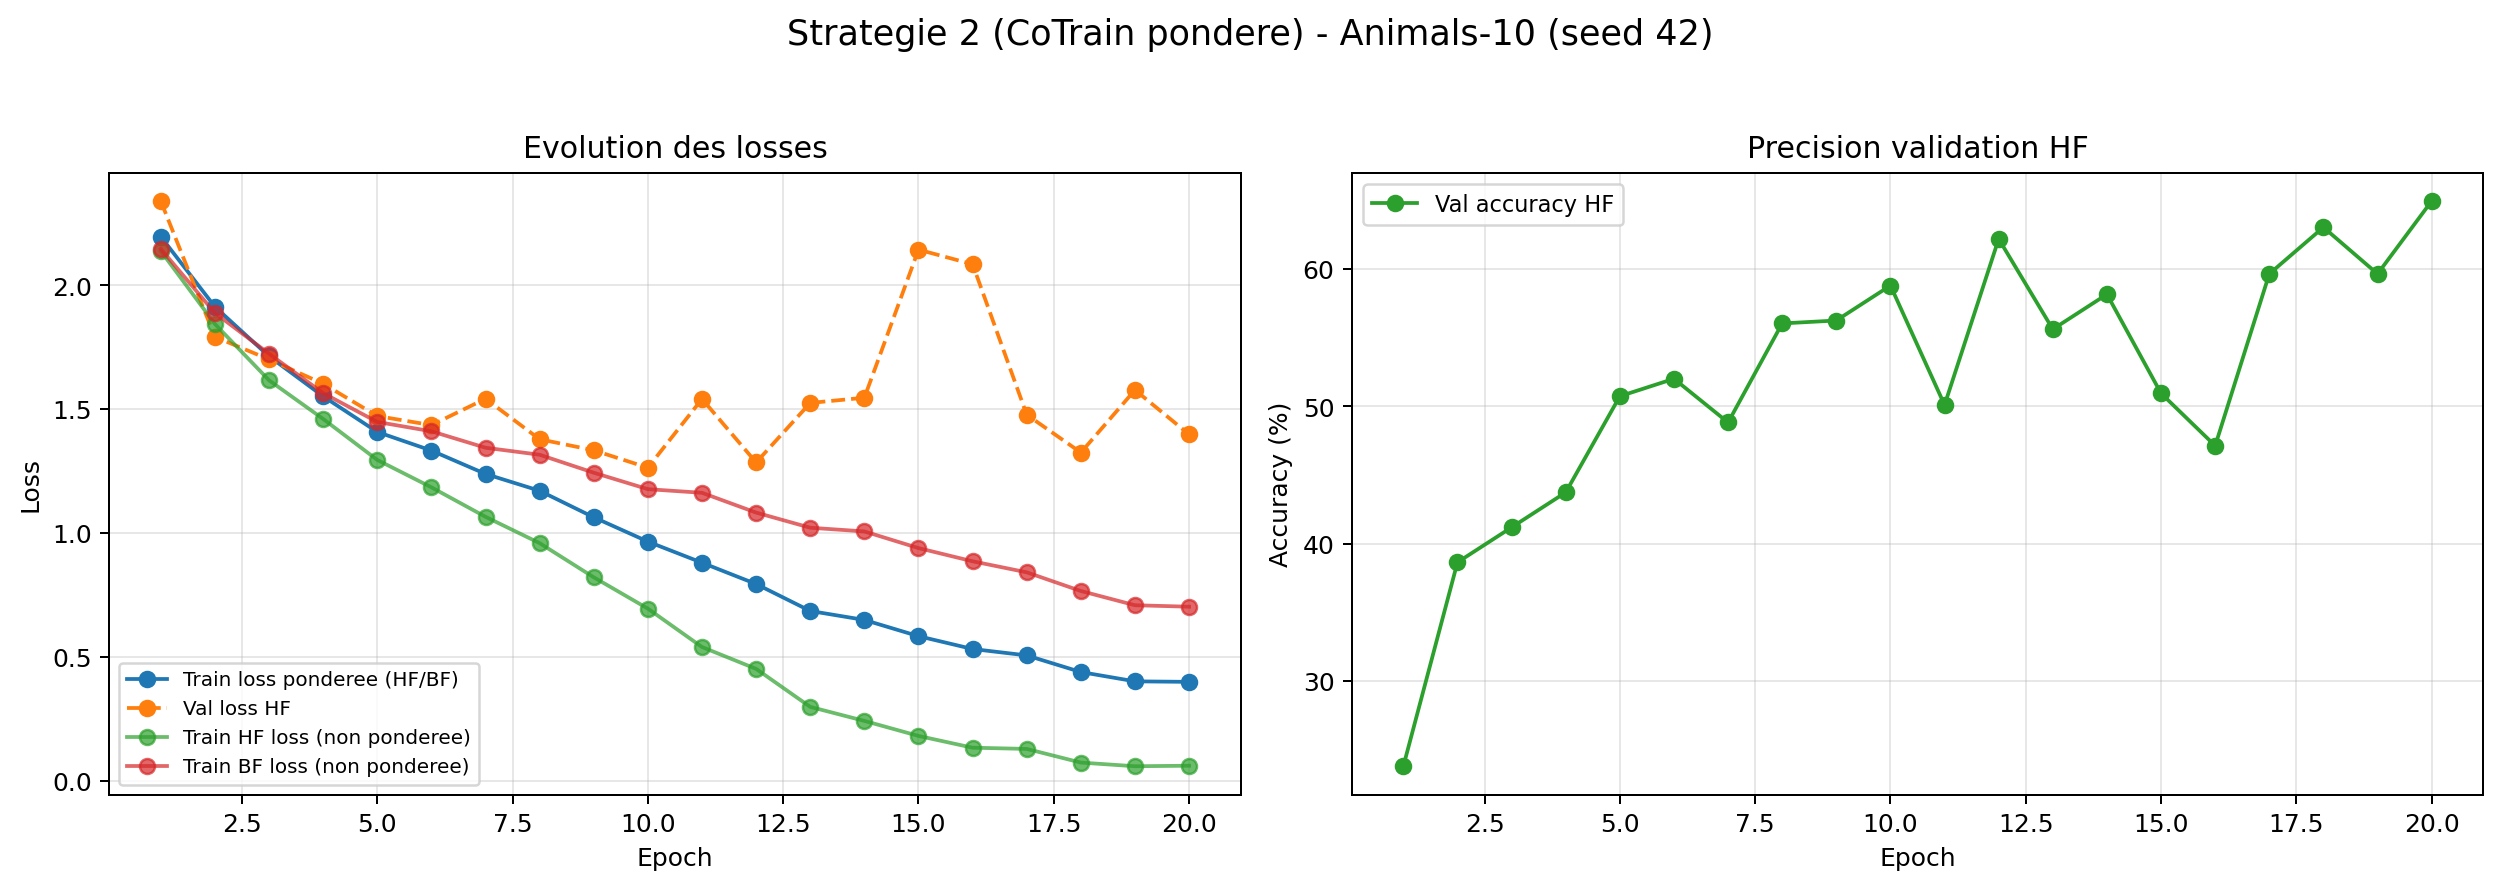

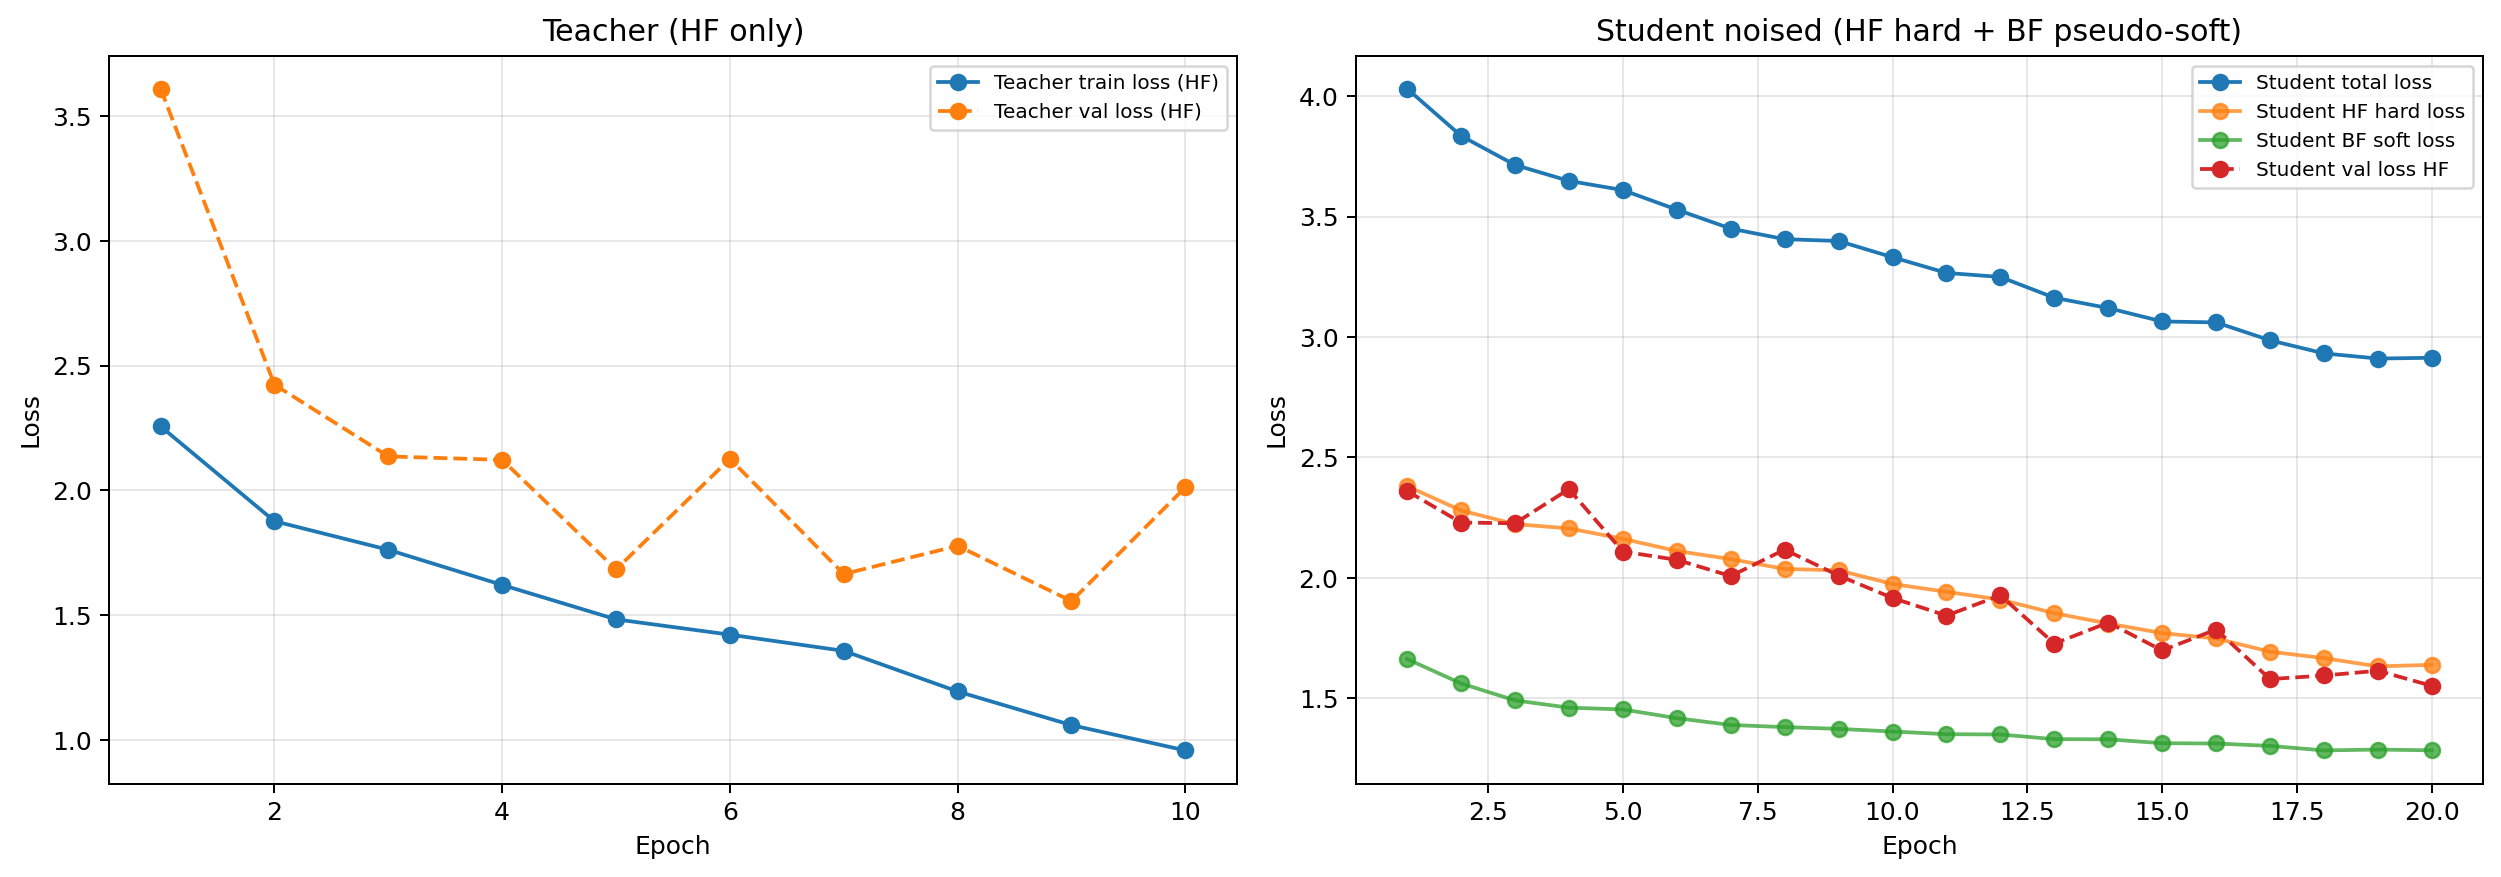

**Imagewoof**

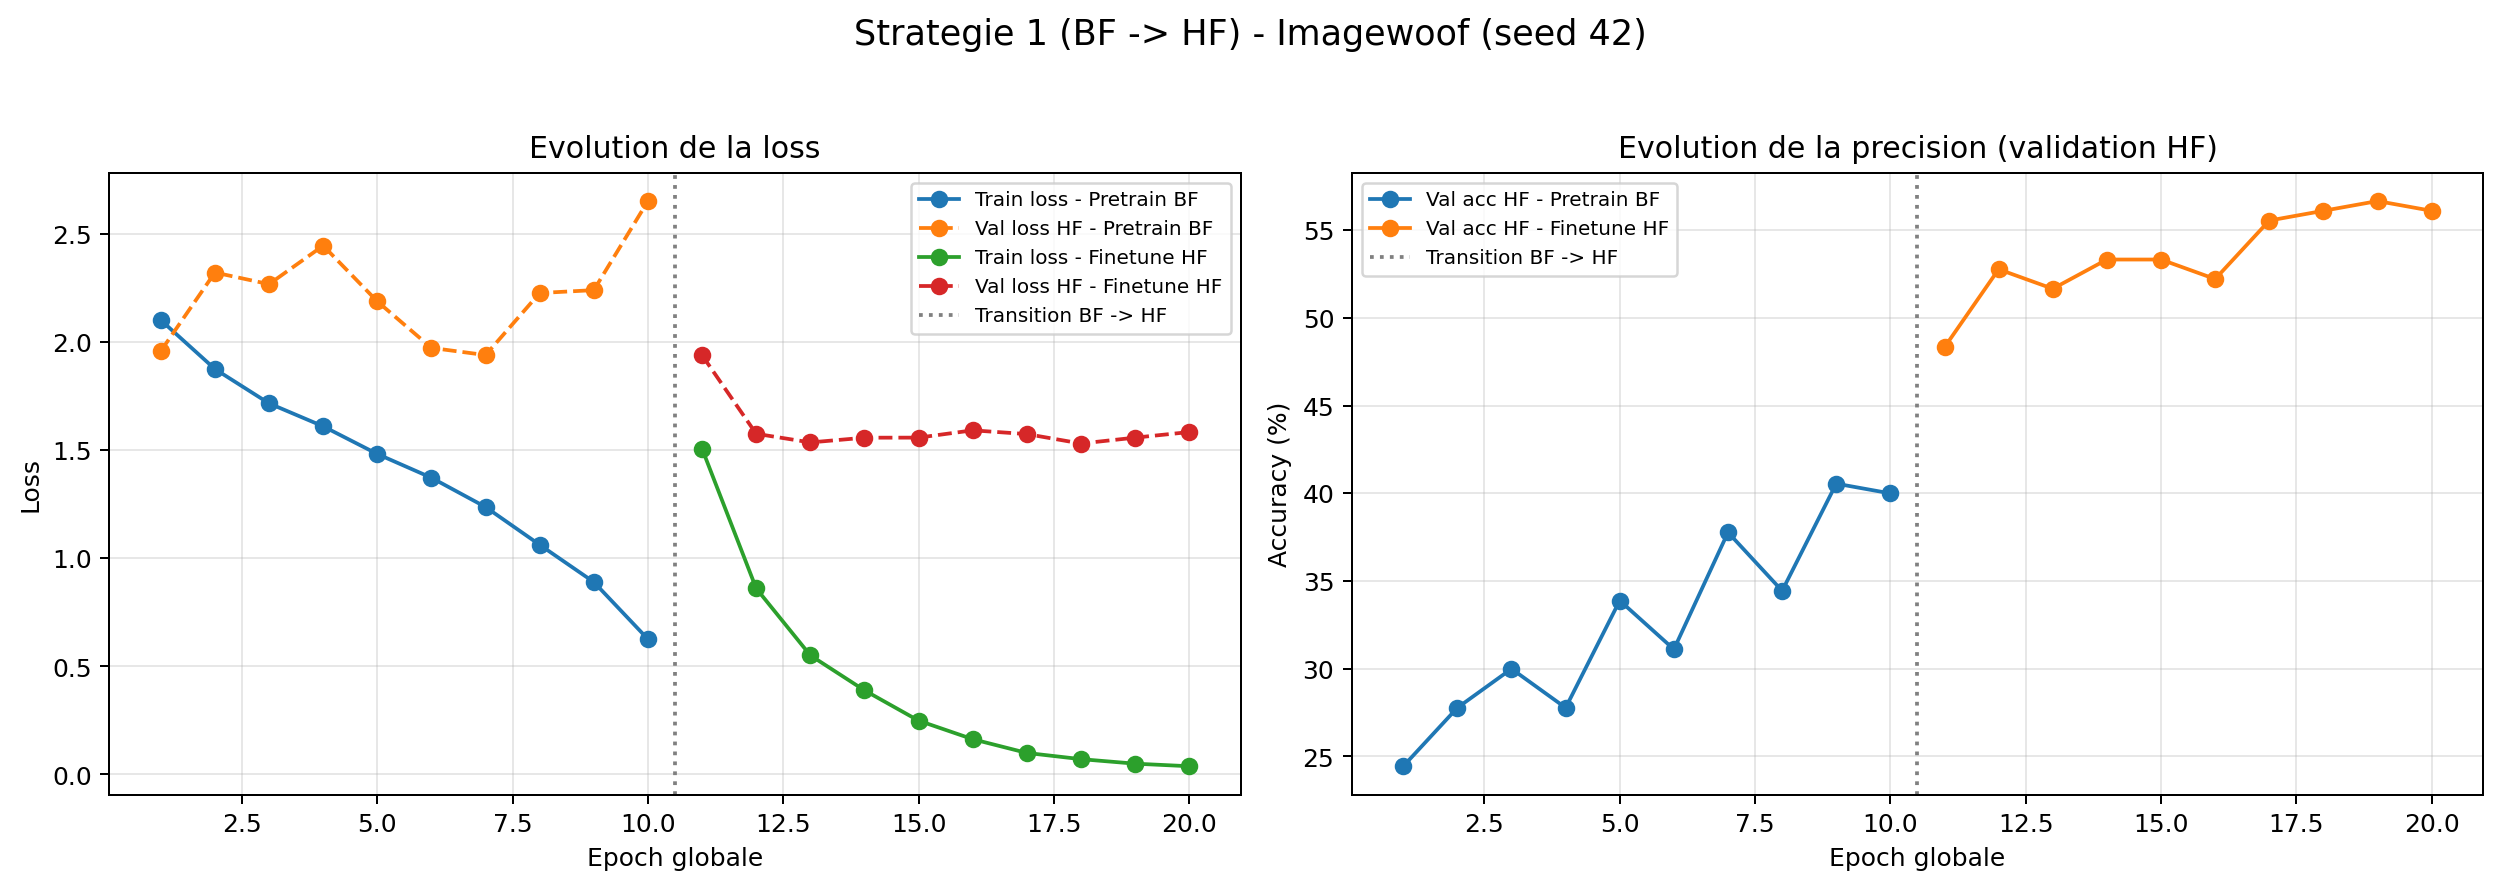

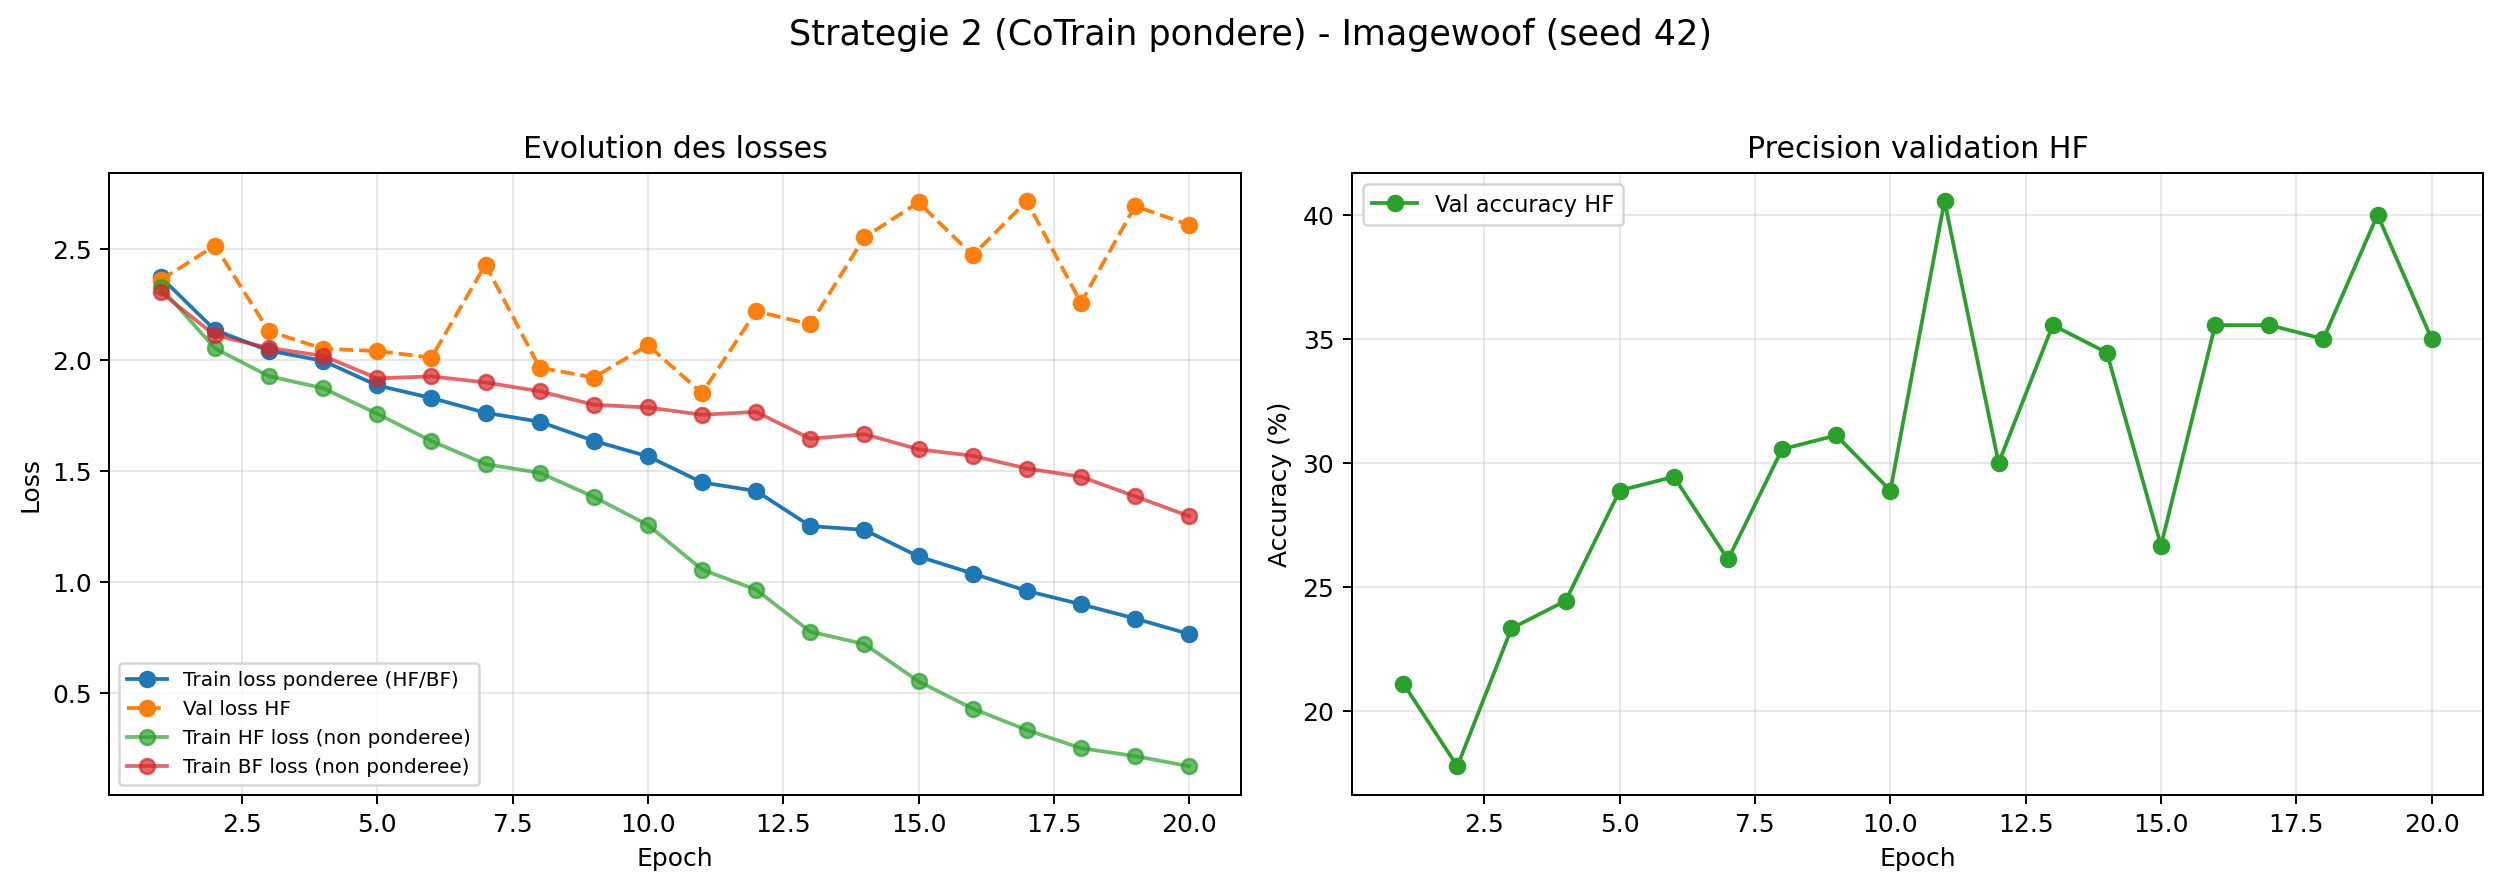

In [11]:
display(Markdown('**Animals-10**'))
for fn in ['strategy1_transfer_learning_curves.png',
           'strategy2_cotraining_reweighting_curves.png',
           'strategy3_noisy_student_curves.png']:
    show(os.path.join(RES['Animals-10'], fn))

display(Markdown('**Imagewoof**'))
for fn in ['strategy1_transfer_learning_curves.png',
           'strategy2_cotraining_reweighting_curves.png']:
    show(os.path.join(RES['Imagewoof'], fn))

## 9) Conclusion générale

- **Stratégie 1 (transfer learning séquentiel BF→HF)** est la méthode recommandée :
  meilleure précision Test HF sur **les deux datasets** (78,4 % Animals, 52,0 %
  Imagewoof), la **plus stable** (plus faible écart-type sur 3 seeds), à **budget
  données identique** à la borne mixte BL3 mais avec **environ deux fois moins de
  calcul et de coût total**.
- Les deux phénomènes fondamentaux sont confirmés et quantifiés : **domain shift**
  (un modèle HF pur s'effondre sur le domaine dégradé) et **paradoxe de la quantité**
  (le volume BF bon marché prime sur la perfection d'un petit jeu HF).
- **Stratégie 2** (co-training pondéré) offre le meilleur équilibre HF/BF sur
  Animals-10 mais décroche sur Imagewoof (fine-grained, faible volume HF).
- **Stratégie 3** (Noisy Student) n'est pas adaptée en l'état (teacher trop faible,
  pseudo-labels bruités, coût le plus élevé).
- L'analyse de **robustesse** et de **sensibilité au ratio** précise les limites :
  les modèles exposés au BF généralisent mieux à la dégradation, et le « meilleur »
  par efficacité dépend du ratio de coût — alors que la précision HF absolue désigne
  systématiquement la Stratégie 1.